### 법학 분류

In [15]:
import pandas as pd

def debug_prompt_text(input_file):
    # 데이터 로드
    df = pd.read_csv(input_file)
    # 중복 제거 (실제 파이프라인과 동일하게)
    unique_papers = df.drop_duplicates(subset=['source_id']).head(3)
    
    print("="*30)
    print("🚀 [DEBUG] API 전송 예정 텍스트 샘플")
    print("="*30)
    
    for i, (_, row) in enumerate(unique_papers.iterrows()):
        # 실제 classify_batch 함수에서 만드는 것과 동일한 로직
        items_text = f"- 제목: {row['source_title']} / 키워드: {row['source_keywords']}\n"
        
        print(f"[{i+1}번 논문 전송 텍스트]:")
        print(items_text)
        print("-" * 30)

# 실행 (상세데이터 파일명을 넣으세요)
debug_prompt_text('법학_인용_AI_논문_상세데이터.csv')

🚀 [DEBUG] API 전송 예정 텍스트 샘플
[1번 논문 전송 텍스트]:
- 제목: 인공지능(AI) 활용 저작물의 편집저작물성과 구성요소의 선택·배열 / 키워드: Edit]]>,Compilation]]>,Compilation Work]]>,Originality]]>,Human Authorship]]>,Artificial Intelligent]]>,Copyright Registration]]>,편집]]>,편집물]]>,편집저작물]]>,구성요소의 선택·배열]]>,창작성]]>,자연인 작성]]>,인공지능]]>,저작권 등록]]>

------------------------------
[2번 논문 전송 텍스트]:
- 제목: 생성형 AI와 편향성 / 키워드: Generative Artificial Intelligence]]>,bias]]>,unrepresentative data]]>,halucinations]]>,fairness]]>,transparency]]>,accountability]]>,inclusivity.]]>,생성형 인공지능]]>,편향성]]>,환각]]>,차별]]>,대표성 없는 데이터]]>,공정성]]>,투명성]]>,설명가능성]]>,포용성]]>

------------------------------
[3번 논문 전송 텍스트]:
- 제목: 인공지능이 생성한 콘텐츠의 저작권 보호 / 키워드: 인공지능]]>,인공지능이 생성한 콘텐츠]]>,인공지능에 의한 창작물]]>,인공지능 저작물]]>,인공지능 저작물의 저작자]]>,창작적 기여도.]]>,Artificial Intelligence]]>,Artificial Intelligence-generated Content]]>,Creations by Artificial Intelligence]]>,Artificial Intelligence Works]]>,Authors of Artificial Intelligence Works]]>,Creative Contribution]]>

---------------------------

In [16]:
import pandas as pd
import google.generativeai as genai
from pydantic import BaseModel
from typing import List
from tqdm import tqdm
import time
import os
import json
from dotenv import load_dotenv

# 0. 설정 로드
load_dotenv()
API_KEY = os.getenv("GOOGLE_API_KEY")
# 현재 작업 경로 출력 (파일이 있는 곳과 일치하는지 확인용)
print(f"현재 작업 경로: {os.getcwd()}")

# .env 파일이 현재 경로에 있는지 확인
if os.path.exists('.env'):
    print("✅ .env 파일을 찾았습니다!")
else:
    print("❌ .env 파일이 현재 경로에 없습니다. 파일 이름을 확인하거나 경로를 체크하세요.")

print(f"DEBUG: 로드된 API 키 확인: {API_KEY[:4] if API_KEY else 'None'}...")

if not API_KEY:
    print("❌ 에러: .env 파일에서 API 키를 읽어오지 못했습니다. 파일 위치나 변수명을 확인하세요.")

# 1. Pydantic 모델 정의 (구조화된 출력 강제)
class ClassificationItem(BaseModel):
    title: str
    category: str  # 공법, 민사법, 형사법, 기타/전문 중 하나

class BatchClassificationResponse(BaseModel):
    results: List[ClassificationItem]

# 2. API 설정
genai.configure(api_key=API_KEY)
# 속도와 비용을 생각하면 1.5-flash도 충분히 훌륭하며, 정교한 분류는 1.5-pro를 추천합니다.
model = genai.GenerativeModel('gemini-2.5-pro') 

def classify_batch(batch_df):
    """20개의 논문을 하나의 프롬프트로 묶어 분류 요청 (데이터 세척 로직 추가)"""
    items_text = ""
    for _, row in batch_df.iterrows():
        # [수정] 키워드에서 ']]>' 잔재를 제거하고 앞뒤 공백을 정리합니다.
        raw_keywords = str(row['source_keywords']) # 문자열 변환
        clean_keywords = raw_keywords.replace(']]>', '').strip()
        
        items_text += f"- 제목: {row['source_title']} / 키워드: {clean_keywords}\n"

    prompt = f"""
    너는 한국 법학 논문 분류 전문가야. 아래 논문들의 제목과 키워드를 읽고 각 논문을 아래 4개 카테고리 중 하나로 분류해줘.
    
    [분류 기준]
    1. 공법: 헌법, 행정법, 국가규제, 개인정보보호법, 인권, 선거, 정보주체 등
    2. 민사법: 민법, 상법, 불법행위, 손해배상, 계약, 민사책임, 대위 등
    3. 형사법: 형법, 형사소송법, 범죄, 처벌, 수사, 딥페이크 성범죄, 디지털 교도소 등
    4. 기타/전문: 지식재산권(저작권/특허), 노동법, 법철학, 법윤리, 경제법, 국제법 등

    [대상 리스트]
    {items_text}
    
    각 논문에 대해 원래 제목(title)을 그대로 유지하면서 분류 결과(category)를 JSON 형식으로 반환해.
    """

    try:
        # Pydantic 모델을 response_schema로 전달하여 응답 구조를 강제합니다.
        response = model.generate_content(
            prompt,
            generation_config=genai.GenerationConfig(
                response_mime_type="application/json",
                response_schema=BatchClassificationResponse # 정의한 모델명으로 수정
            )
        )
        return response.text
    except Exception as e:
        print(f"⚠️ API 호출 중 오류 발생: {e}")
        return None
    
def run_classification_pipeline(input_file, master_file, output_file):
    # 1. 상세 데이터 로드 (source_id, 제목, 키워드 등 포함)
    print("📋 상세 데이터를 로드하는 중...")
    df_detail = pd.read_csv(input_file)
    
    # 2. 마스터 데이터 로드 (논문 ID, 발행연도 포함)
    print("📚 마스터 노드 데이터를 로드하는 중...")
    df_master = pd.read_csv(master_file)
    
    # 3. 데이터 합치기 (Join)
    # df_detail의 'source_id'와 df_master의 '논문 ID'를 기준으로 병합
    print("🔗 데이터를 결합하여 발행연도 정보를 가져오는 중...")
    df = df_detail.merge(
        df_master[['논문ID', '발행연도']], 
        left_on='source_id', 
        right_on='논문ID', 
        how='left'
    )
    
    # 4. 중복 제거 (논문 한 건당 여러 참고문헌이 있어 중복된 source_id가 많을 수 있음)
    unique_papers = df.drop_duplicates(subset=['source_id']).copy()
    print(f"✅ 총 {len(unique_papers)}건의 고유 논문을 분류할 예정입니다.")
    
    batch_size = 20
    final_results = []

    # 5. LLM 분류 루프 (이하 동일)
    for i in tqdm(range(0, len(unique_papers), batch_size), desc="LLM 분류 진행 중"):
        batch_df = unique_papers.iloc[i : i + batch_size]
        
        json_response = classify_batch(batch_df)
        
        if json_response:
            try:
                parsed_data = json.loads(json_response)
                for res, (_, original_row) in zip(parsed_data['results'], batch_df.iterrows()):
                    final_results.append({
                        '논문제목': original_row['source_title'],
                        '키워드': original_row['source_keywords'],
                        '출판연도': original_row['발행연도'], # 이제 에러 없이 가져옵니다!
                        '분류': res['category'],
                        'source_id': original_row['source_id']
                    })
            except Exception as e:
                print(f"❌ {i}번째 배치 파싱 에러: {e}")
        
        time.sleep(2)

    # 6. 최종 결과 저장
    result_df = pd.DataFrame(final_results)
    result_df.to_csv(output_file, index=False, encoding='utf-8-sig')
    print(f"🏁 모든 분류가 완료되었습니다: {output_file}")  
    print("-" * 50)
    print(f"✅ 분류 완료! 총 {len(result_df)}건의 데이터가 '{output_file}'에 저장되었습니다.")
    print(result_df['분류'].value_counts()) # 간이 통계 출력

# 실행
if __name__ == "__main__":
    run_classification_pipeline(
    input_file='법학_인용_AI_논문_상세데이터.csv', 
    master_file='전체_법학_논문목록_정제본.csv', 
    output_file='AI_논문_분야별_분류_최종.csv'
)

현재 작업 경로: c:\Users\silve\Documents\GitHub\kci_network
✅ .env 파일을 찾았습니다!
DEBUG: 로드된 API 키 확인: AIza...
📋 상세 데이터를 로드하는 중...
📚 마스터 노드 데이터를 로드하는 중...
🔗 데이터를 결합하여 발행연도 정보를 가져오는 중...
✅ 총 1266건의 고유 논문을 분류할 예정입니다.


LLM 분류 진행 중:  34%|███▍      | 22/64 [12:39<24:20, 34.78s/it]

❌ 440번째 배치 파싱 에러: Unterminated string starting at: line 4 column 16 (char 38)


LLM 분류 진행 중: 100%|██████████| 64/64 [43:32<00:00, 40.82s/it]   

🏁 모든 분류가 완료되었습니다: AI_논문_분야별_분류_최종.csv
--------------------------------------------------
✅ 분류 완료! 총 1246건의 데이터가 'AI_논문_분야별_분류_최종.csv'에 저장되었습니다.
분류
기타/전문    585
공법       339
민사법      173
형사법      149
Name: count, dtype: int64


✅ 점유율 계산 완료! '분야별_점유율_추이.csv' 파일이 생성되었습니다.


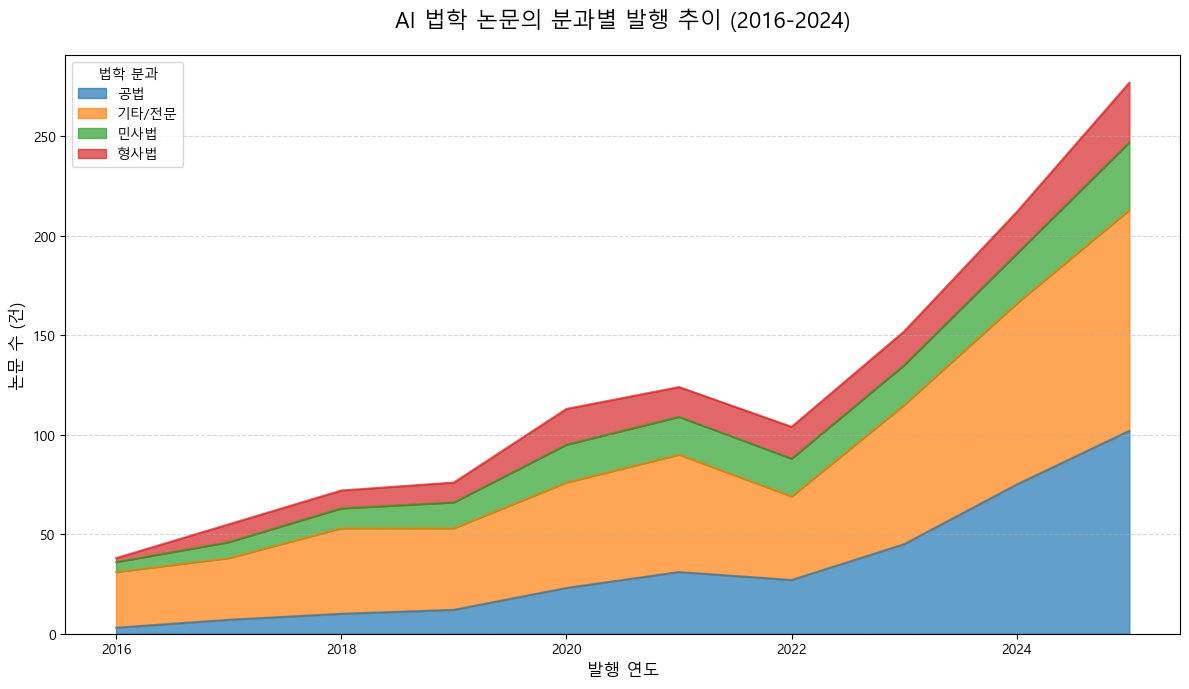

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# 한글 폰트 설정
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

def plot_yearly_trends_with_share(file_path):
    # 1. 데이터 로드 및 필터링
    df = pd.read_csv(file_path)
    df = df[df['출판연도'] >= 2016]
    
    # 2. 연도별/분류별 논문 '건수' 집계
    count_df = df.groupby(['출판연도', '분류']).size().unstack(fill_value=0)
    
    # 3. 점유율(%) 계산
    # 각 연도별 합계로 나누어 백분율을 구합니다.
    # 계산식: (해당 분야 건수 / 해당 연도 전체 건수) * 100
    share_df = count_df.div(count_df.sum(axis=1), axis=0) * 100
    
    # 4. CSV 파일 저장
    # '분야별_점유율_추이.csv'로 저장합니다.
    share_df.to_csv('분야별_점유율_추이.csv', encoding='utf-8-sig')
    print(f"✅ 점유율 계산 완료! '분야별_점유율_추이.csv' 파일이 생성되었습니다.")
    
    # 5. 시각화 (기존 로직 유지)
    plt.figure(figsize=(12, 7))
    count_df.plot(kind='area', stacked=True, alpha=0.7, ax=plt.gca())
    
    plt.title('AI 법학 논문의 분과별 발행 추이 (2016-2024)', fontsize=16, pad=20)
    plt.xlabel('발행 연도', fontsize=12)
    plt.ylabel('논문 수 (건)', fontsize=12)
    plt.legend(title='법학 분과', loc='upper left')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig('분야별_발행추이.png', dpi=300)
    plt.show()


plot_yearly_trends_with_share('AI_논문_분야별_분류_최종.csv')

✅ 전체 점유율 통계 완료! '전체_분야별_점유율_합계.csv'가 생성되었습니다.


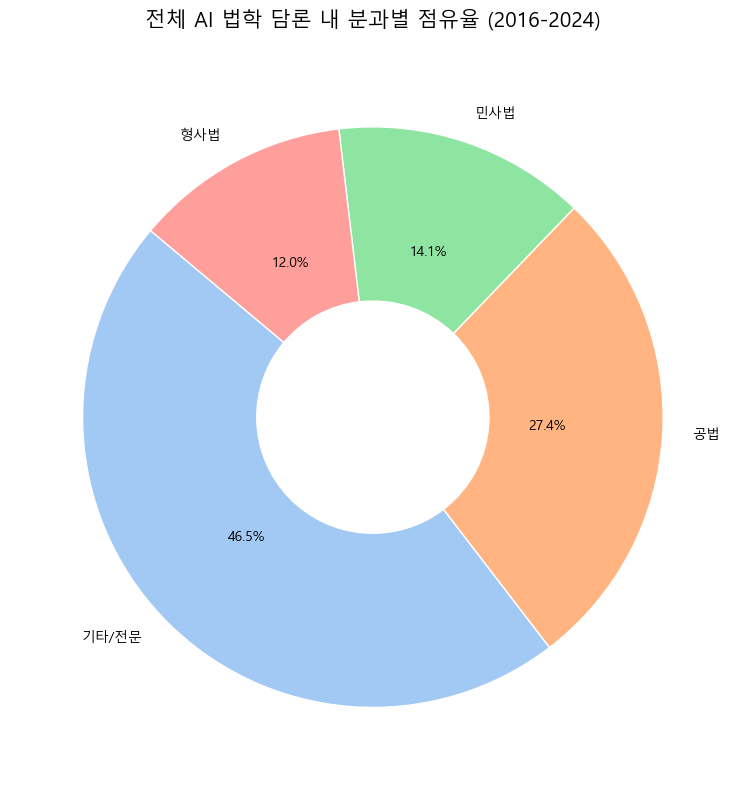

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_category_distribution(file_path):
    # 1. 데이터 로드 및 필터링
    df = pd.read_csv(file_path)
    df = df[df['출판연도'] >= 2016]
    
    # 2. 통계 계산 (건수 및 비중)
    counts = df['분류'].value_counts()
    percentages = df['분류'].value_counts(normalize=True) * 100
    
    # 3. 데이터프레임 생성 및 CSV 저장
    dist_df = pd.DataFrame({
        '건수': counts,
        '비중(%)': percentages.round(2)
    })
    
    # 인덱스 이름(분류)을 명시적으로 지정하여 저장
    dist_df.index.name = '법학_분과'
    dist_df.to_csv('전체_분야별_점유율_합계.csv', encoding='utf-8-sig')
    print(f"✅ 전체 점유율 통계 완료! '전체_분야별_점유율_합계.csv'가 생성되었습니다.")
    
    # 4. 시각화 (도넛 차트 형태)
    plt.figure(figsize=(8, 8))
    colors = sns.color_palette('pastel')[0:4]
    
    plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=140, 
            colors=colors, wedgeprops={'edgecolor': 'white', 'width': 0.6})
    
    plt.title('전체 AI 법학 담론 내 분과별 점유율 (2016-2024)', fontsize=15, pad=20)
    plt.tight_layout()
    plt.savefig('분야별_점유율.png', dpi=300)
    plt.show()

plot_category_distribution('AI_논문_분야별_분류_최종.csv')

### 키워드

✅ 분석 완료! 'AI_법학_전체기간_누적_핵심키워드.csv'가 저장되었습니다.


C:\Users\silve\AppData\Local\Temp\ipykernel_32668\1759887864.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='누적빈도', y='키워드', data=result_df, palette='viridis')


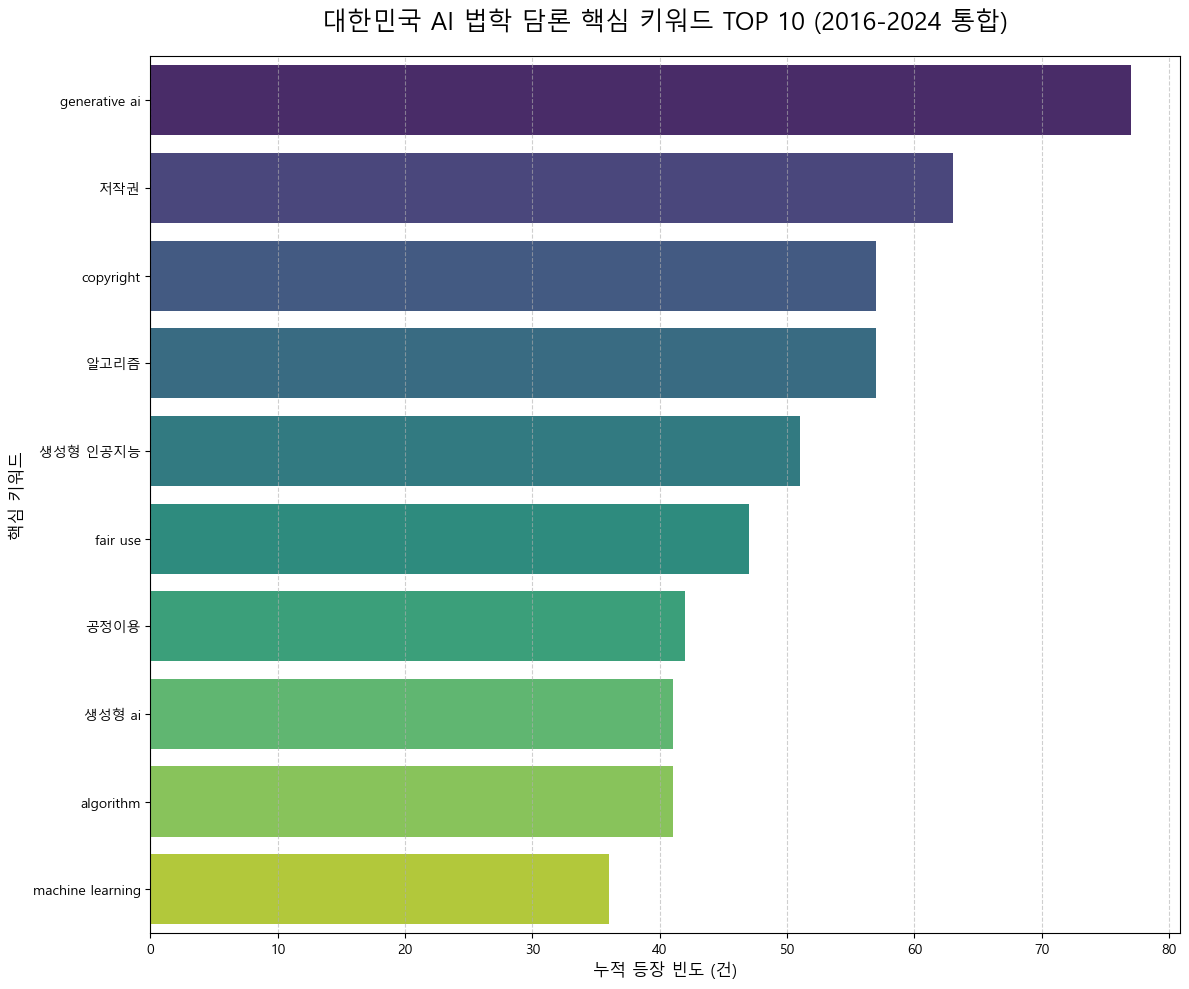

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# 한글 폰트 설정
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

def analyze_total_aggregated_keywords(file_path):
    # 1. 데이터 로드 및 전처리
    df = pd.read_csv(file_path)
    df = df[df['출판연도'] >= 2016]
    
    # 논문 ID 기준 중복 제거 (필수)
    unique_papers = df.drop_duplicates(subset=['source_id']).copy()
    
    def clean_kw(kw_str):
        if pd.isna(kw_str): return []
        words = str(kw_str).replace(']]>', '').split(',')
        # 소문자 통합 및 공백 제거
        cleaned = [w.strip().lower() for w in words if w.strip()]
        # 불용어 리스트 강화 (법학 논문 일반 용어 제거)
        stopwords = ['인공지능', 'ai', 'artificial intelligence', 'artificial intelligence(ai)']
        return [w for w in cleaned if w not in stopwords]

    unique_papers['cleaned_keywords'] = unique_papers['키워드'].apply(clean_kw)

    # 2. 전체 기간 키워드 통합 및 빈도 계산
    all_keywords = unique_papers['cleaned_keywords'].sum()
    # 상위 30개 추출
    total_top_30 = Counter(all_keywords).most_common(10)

    # 3. CSV 파일 저장
    result_df = pd.DataFrame(total_top_30, columns=['키워드', '누적빈도'])
    result_df.to_csv('AI_법학_전체기간_누적_핵심키워드.csv', index=False, encoding='utf-8-sig')
    print(f"✅ 분석 완료! 'AI_법학_전체기간_누적_핵심키워드.csv'가 저장되었습니다.")

    # 4. 시각화 (상위 30개 가로 바 차트)
    plt.figure(figsize=(12, 10))
    sns.barplot(x='누적빈도', y='키워드', data=result_df, palette='viridis')
    
    plt.title('대한민국 AI 법학 담론 핵심 키워드 TOP 10 (2016-2024 통합)', fontsize=18, pad=20)
    plt.xlabel('누적 등장 빈도 (건)', fontsize=12)
    plt.ylabel('핵심 키워드', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.savefig('전체기간_누적_키워드_분석.png', dpi=300)
    plt.show()

# 실행
analyze_total_aggregated_keywords('AI_논문_분야별_분류_최종.csv')

✅ 분석 완료! '연도별_전체_핵심키워드_변천사.csv'가 저장되었습니다.


C:\Users\silve\AppData\Local\Temp\ipykernel_32668\2669803157.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='빈도', y='키워드', data=year_data, ax=axes[i], palette='crest')
C:\Users\silve\AppData\Local\Temp\ipykernel_32668\2669803157.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='빈도', y='키워드', data=year_data, ax=axes[i], palette='crest')
C:\Users\silve\AppData\Local\Temp\ipykernel_32668\2669803157.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='빈도', y='키워드', data=year_data, ax=axes[i], palette='crest')
C:\Users\silve\AppD

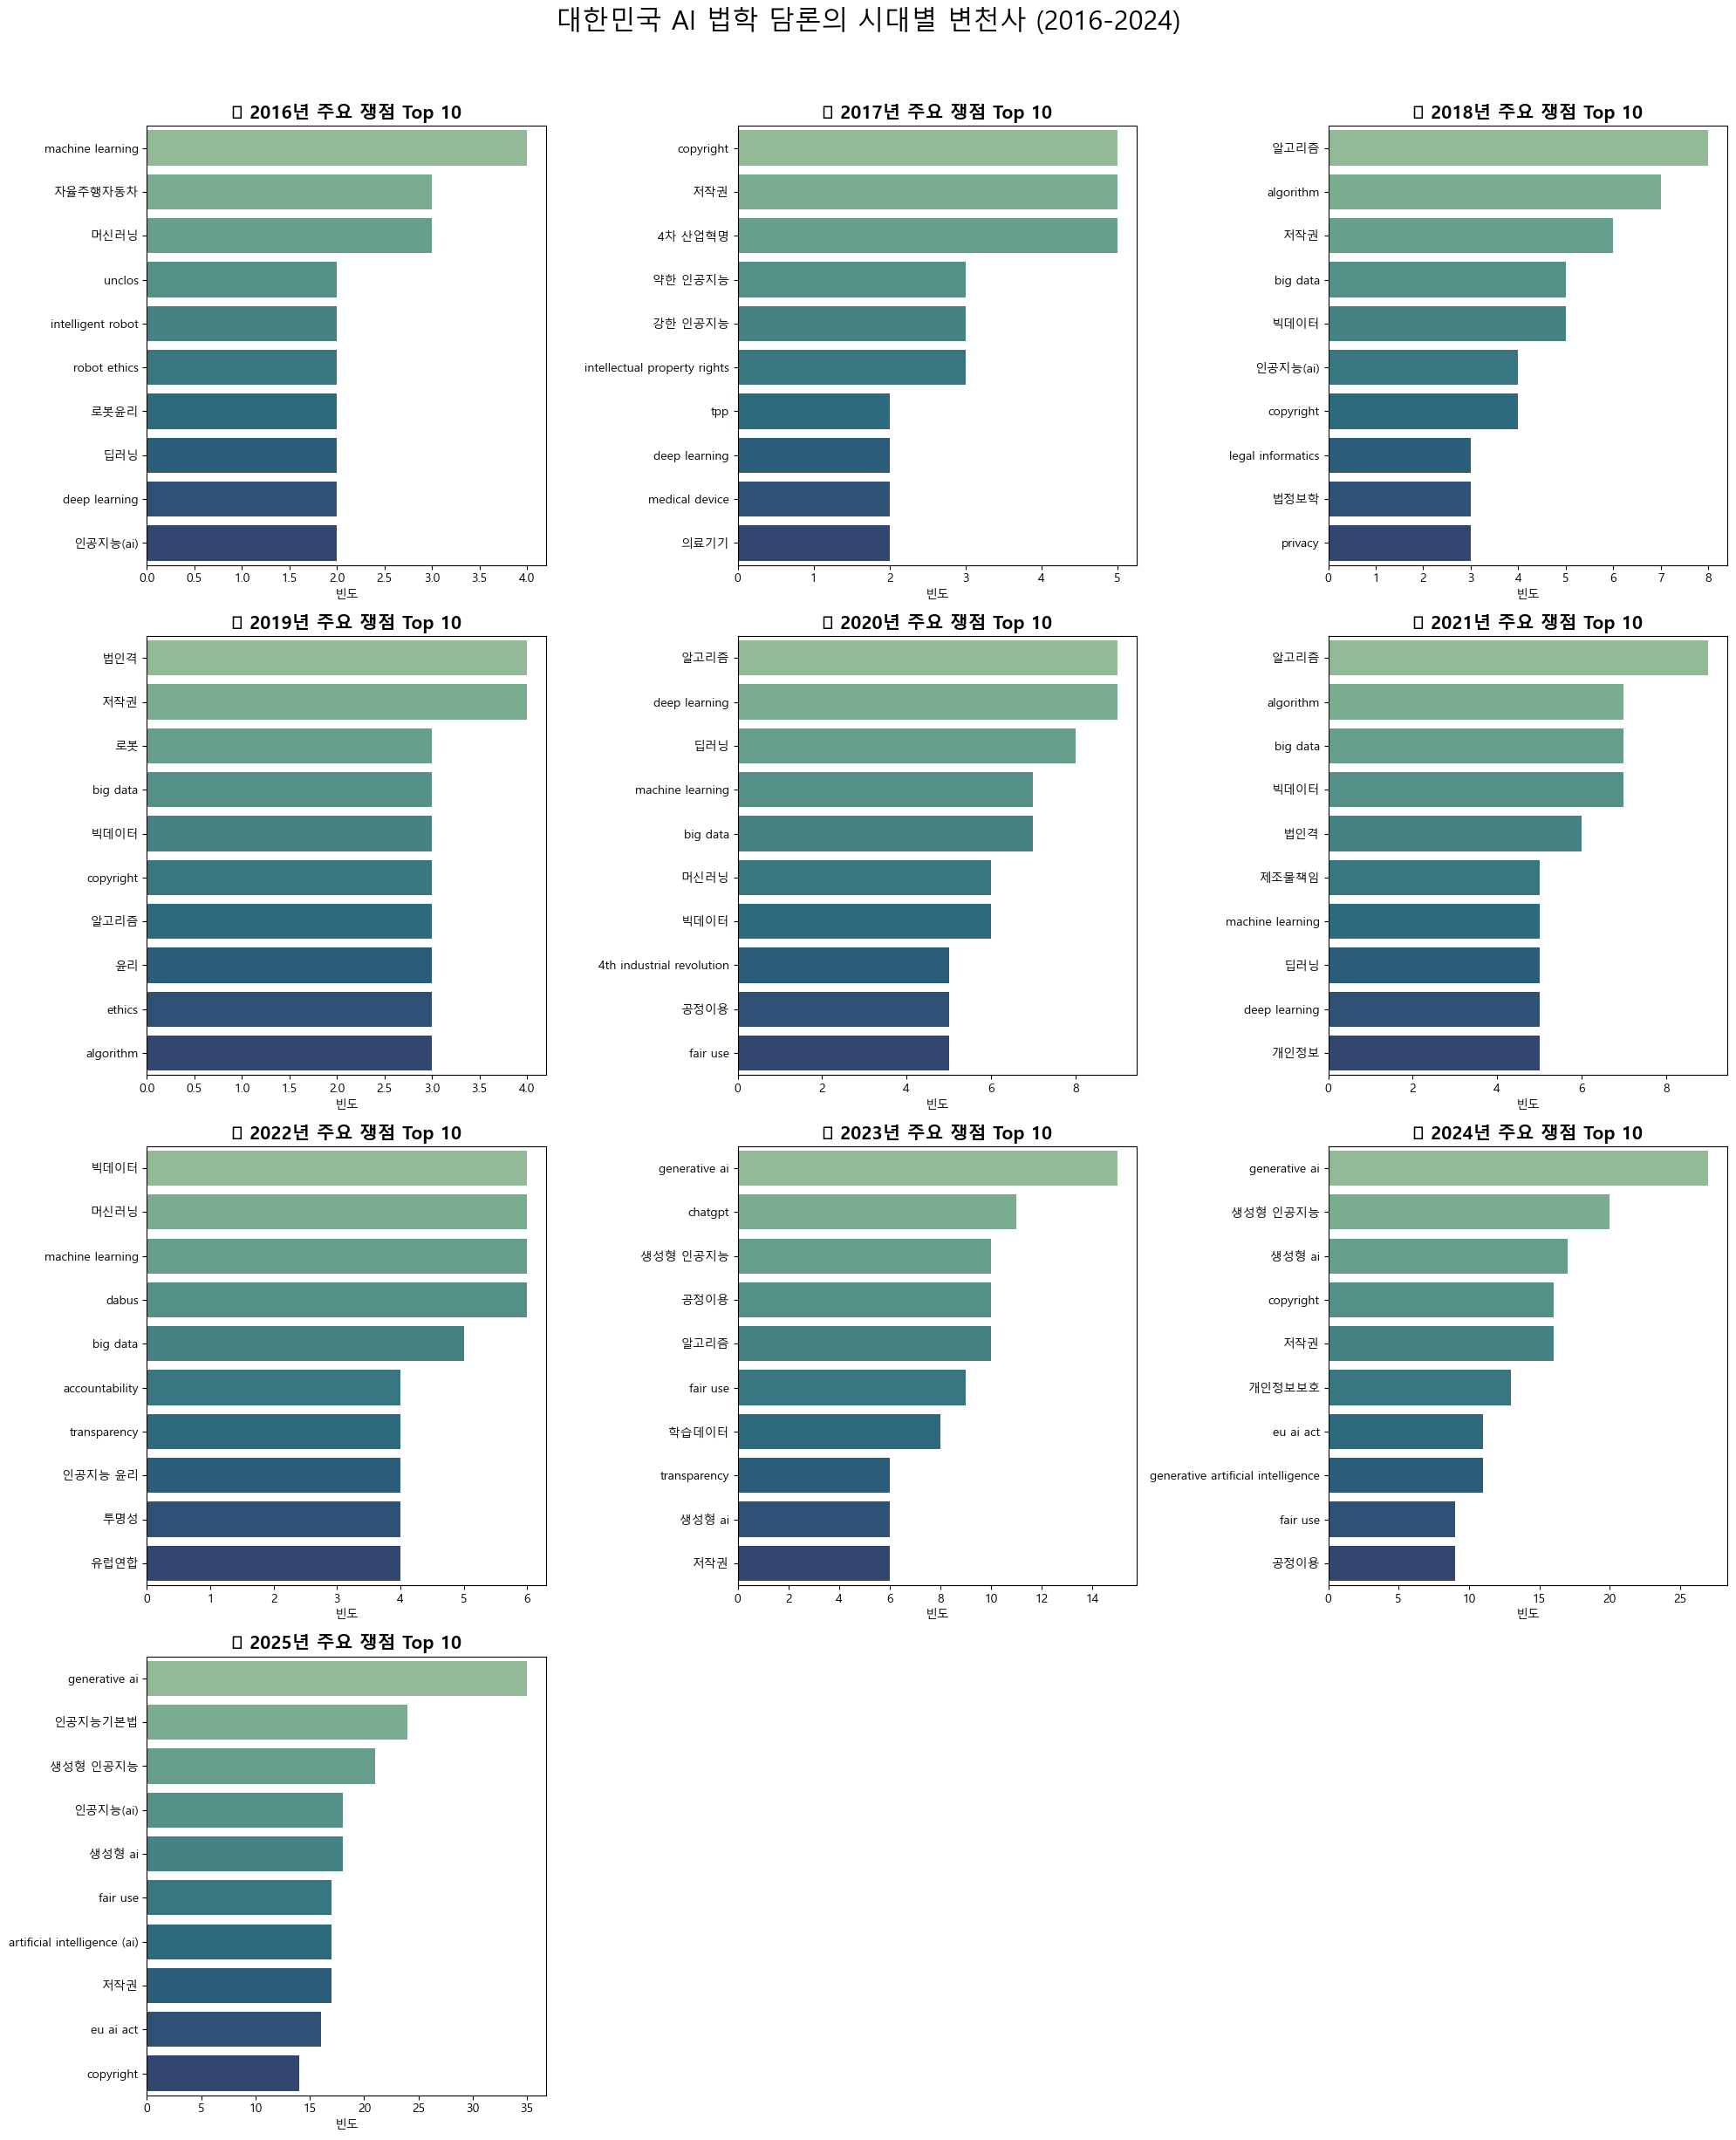

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import math

# 한글 폰트 설정
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

def analyze_yearly_keyword_transition(file_path):
    # 1. 데이터 로드 및 전처리
    df = pd.read_csv(file_path)
    df = df[df['출판연도'] >= 2016]
    
    # 논문 ID 기준 중복 제거 (데이터 신뢰도 확보)
    unique_papers = df.drop_duplicates(subset=['source_id']).copy()
    
    def clean_kw(kw_str):
        if pd.isna(kw_str): return []
        # ']]>' 제거 및 쉼표 분리
        words = str(kw_str).replace(']]>', '').split(',')
        # 소문자 통합 및 공백 제거
        cleaned = [w.strip().lower() for w in words if w.strip()]
        # 법학 논문 특유의 일반 단어 및 불용어 제외
        stopwords = ['인공지능', 'ai', 'artificial intelligence', 'artificial intelligence(ai)']
        return [w for w in cleaned if w not in stopwords]

    unique_papers['cleaned_keywords'] = unique_papers['키워드'].apply(clean_kw)

    # 2. 연도별 Top 10 추출 및 CSV용 데이터 구성
    years = sorted(unique_papers['출판연도'].unique())
    num_years = len(years)
    
    yearly_results = []
    
    for year in years:
        # 해당 연도의 모든 논문 키워드 통합 (분류 무시)
        year_kws = unique_papers[unique_papers['출판연도'] == year]['cleaned_keywords'].sum()
        top_10 = Counter(year_kws).most_common(10)
        
        for rank, (word, freq) in enumerate(top_10, 1):
            yearly_results.append({
                '연도': int(year),
                '순위': rank,
                '키워드': word,
                '빈도': freq
            })

    # CSV 파일 저장
    result_df = pd.DataFrame(yearly_results)
    result_df.to_csv('연도별_전체_핵심키워드_변천사.csv', index=False, encoding='utf-8-sig')
    print(f"✅ 분석 완료! '연도별_전체_핵심키워드_변천사.csv'가 저장되었습니다.")

    # 3. 시각화 (연도별 Top 10 바 차트 그리드)
    cols = 3
    rows = math.ceil(num_years / cols)
    
    fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 6))
    axes = axes.flatten()

    for i, year in enumerate(years):
        year_data = result_df[result_df['연도'] == year]
        
        if not year_data.empty:
            sns.barplot(x='빈도', y='키워드', data=year_data, ax=axes[i], palette='crest')
            axes[i].set_title(f'🚀 {year}년 주요 쟁점 Top 10', fontsize=15, fontweight='bold')
            axes[i].set_xlabel('빈도')
            axes[i].set_ylabel('')

    # 빈 칸 제거
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.suptitle('대한민국 AI 법학 담론의 시대별 변천사 (2016-2024)', fontsize=22, y=1.02)
    plt.tight_layout()
    plt.savefig('연도별_전체_키워드_변천사.png', dpi=300, bbox_inches='tight')
    plt.show()

# 실행
analyze_yearly_keyword_transition('AI_논문_분야별_분류_최종.csv')

C:\Users\silve\AppData\Local\Temp\ipykernel_32668\1109224914.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts, y=words, ax=axes[i], palette='viridis')
C:\Users\silve\AppData\Local\Temp\ipykernel_32668\1109224914.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts, y=words, ax=axes[i], palette='viridis')
C:\Users\silve\AppData\Local\Temp\ipykernel_32668\1109224914.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts, y=words, ax=axes[i], palette='viridis')
C:\Users\silve\AppData\Local\Temp\ipykernel_32668\11092

✅ 분야별 키워드 빈도 분석 완료! '분야별_핵심키워드_빈도_데이터.csv'가 생성되었습니다.


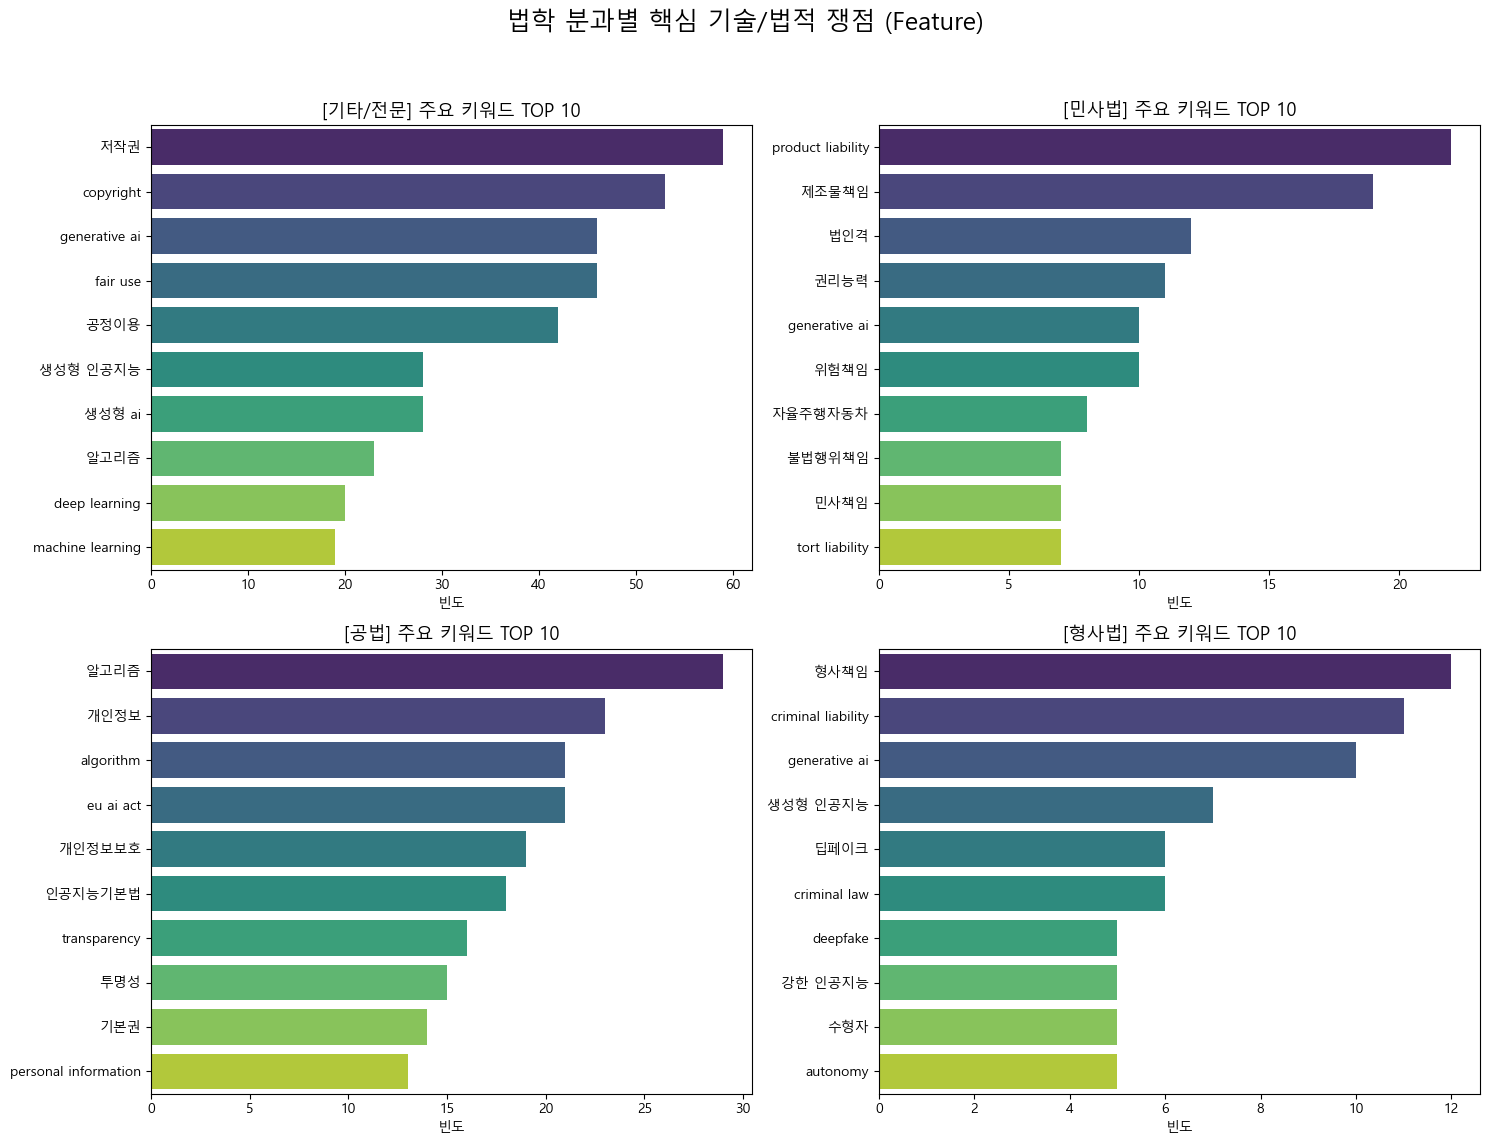

In [9]:
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_and_save_top_keywords(file_path):
    # 1. 데이터 로드 및 필터링
    df = pd.read_csv(file_path)
    df = df[df['출판연도'] >= 2016]
    categories = df['분류'].unique()
    
    # 데이터를 저장할 리스트 초기화
    csv_data = []
    
    # 시각화 설정 (2x2 서브플롯)
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    axes = axes.flatten()
    plt.rc('font', family='Malgun Gothic') 
    
    # 제외할 단어 리스트 (비교를 위해 모두 소문자로 작성)
    exclude_terms = ['인공지능', 'ai', 'artificial intelligence', 'artificial intelligence(ai)']

    for i, cat in enumerate(categories):
        # 해당 카테고리의 키워드 추출 및 세척
        raw_keywords = df[df['분류'] == cat]['키워드'].dropna().str.split(',').sum()
        
        clean_keywords = []
        for kw in raw_keywords:
            # [수정] ']]>' 제거, 공백 제거 후 모두 소문자로 변환
            cleaned = kw.replace(']]>', '').strip().lower()
            
            # 의미 없는 단어 및 빈 문자열 제외 (소문자로 변환된 단어와 비교)
            if cleaned and cleaned not in exclude_terms:
                clean_keywords.append(cleaned)
        
        # 2. 빈도 계산 (CSV용으로 상위 50개 추출)
        keyword_counts = Counter(clean_keywords).most_common(50)
        
        # CSV 저장을 위한 리스트 추가
        for word, count in keyword_counts:
            csv_data.append({
                '분류': cat,
                '키워드': word,
                '빈도': count
            })
        
        # 3. 시각화 (차트용으로 상위 10개만 사용)
        if keyword_counts:
            top_10 = keyword_counts[:10]
            words = [x[0] for x in top_10]
            counts = [x[1] for x in top_10]
            
            sns.barplot(x=counts, y=words, ax=axes[i], palette='viridis')
            axes[i].set_title(f'[{cat}] 주요 키워드 TOP 10', fontsize=13)
            axes[i].set_xlabel('빈도')
            axes[i].set_ylabel('')

    # 4. CSV 파일 저장
    result_df = pd.DataFrame(csv_data)
    result_df.to_csv('분야별_핵심키워드_빈도_데이터.csv', index=False, encoding='utf-8-sig')
    print(f"✅ 분야별 키워드 빈도 분석 완료! '분야별_핵심키워드_빈도_데이터.csv'가 생성되었습니다.")

    plt.suptitle('법학 분과별 핵심 기술/법적 쟁점 (Feature)', fontsize=18)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig('분야별_핵심키워드_세척완료.png', dpi=300)
    plt.show()

# 실행
plot_and_save_top_keywords('AI_논문_분야별_분류_최종.csv')

In [ ]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns
# from collections import Counter
# import math
# import os

# # 한글 폰트 설정
# plt.rc('font', family='Malgun Gothic')
# plt.rcParams['axes.unicode_minus'] = False

# def analyze_top_keywords_by_category(file_path):
#     # 1. 데이터 로드 및 전처리
#     df = pd.read_csv(file_path)
#     df = df[df['출판연도'] >= 2016]
#     unique_papers = df.drop_duplicates(subset=['source_id']).copy()
    
#     def clean_kw(kw_str):
#         if pd.isna(kw_str): return []
#         words = str(kw_str).replace(']]>', '').split(',')
#         # 대소문자 통합(lower) 및 공백 제거
#         cleaned = [w.strip().lower() for w in words if w.strip()]
#         # 분석 제외어 (사용자 요청 반영)
#         stopwords = ['인공지능', 'ai', 'artificial intelligence', 'law', 'legal', '연구', '분석']
#         return [w for w in cleaned if w not in stopwords]
    
#     unique_papers['cleaned_keywords'] = unique_papers['키워드'].apply(clean_kw)

#     # 2. 분류별/연도별 데이터 집계
#     categories = unique_papers['분류'].unique()
#     years = sorted(unique_papers['출판연도'].unique())
#     num_years = len(years)
    
#     combined_results = []

#     # 3. 카테고리별 반복 처리
#     for cat in categories:
#         cat_df = unique_papers[unique_papers['분류'] == cat]
#         print(f"📊 [{cat}] 분과 분석 중...")
        
#         # 시각화 설정 (카테고리당 하나의 이미지 생성)
#         cols = 3
#         rows = math.ceil(num_years / cols)
#         fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 5))
#         axes = axes.flatten()
        
#         for i, year in enumerate(years):
#             year_kws = cat_df[cat_df['출판연도'] == year]['cleaned_keywords'].sum()
            
#             # 키워드가 없는 연도 대응
#             if not year_kws:
#                 axes[i].axis('off')
#                 continue
                
#             top_5 = Counter(year_kws).most_common(5)
            
#             # 데이터 저장용 리스트에 추가
#             for rank, (word, freq) in enumerate(top_5, 1):
#                 combined_results.append({
#                     '분류': cat,
#                     '연도': int(year),
#                     '순위': rank,
#                     '키워드': word,
#                     '빈도': freq
#                 })
            
#             # 개별 차트 생성
#             if top_5:
#                 words = [x[0] for x in top_5]
#                 counts = [x[1] for x in top_5]
#                 sns.barplot(x=counts, y=words, ax=axes[i], palette='viridis')
#                 axes[i].set_title(f'📅 {year}년 ({cat})', fontsize=12, fontweight='bold')
#                 axes[i].set_xlabel('')
#                 axes[i].set_ylabel('')

#         # 남는 칸 제거 및 저장
#         for j in range(i + 1, len(axes)):
#             axes[j].axis('off')
            
#         plt.suptitle(f'[{cat}] 분과 연도별 주요 담론 변화', fontsize=20, y=1.02)
#         plt.tight_layout()
#         filename = f'분류별_키워드추이_{cat.replace("/", "_")}.png'
#         plt.savefig(filename, dpi=300, bbox_inches='tight')
#         plt.close() # 메모리 관리를 위해 닫기

#     # 4. 통합 CSV 저장
#     result_df = pd.DataFrame(combined_results)
#     result_df.to_csv('분류별_연도별_핵심_키워드_Top5.csv', index=False, encoding='utf-8-sig')
#     print("-" * 50)
#     print(f"✅ 분석 완료!")
#     print(f"📁 CSV 저장: 분류별_연도별_핵심_키워드_Top5.csv")
#     print(f"🖼️ 이미지 저장: 각 분류별 PNG 파일 생성 완료")

# # 실행
# analyze_top_keywords_by_category('AI_논문_분야별_분류_최종.csv')

📊 [기타/전문] 분과 분석 중...


C:\Users\silve\AppData\Local\Temp\ipykernel_26600\2089957408.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts, y=words, ax=axes[i], palette='viridis')
C:\Users\silve\AppData\Local\Temp\ipykernel_26600\2089957408.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts, y=words, ax=axes[i], palette='viridis')
C:\Users\silve\AppData\Local\Temp\ipykernel_26600\2089957408.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts, y=words, ax=axes[i], palette='viridis')
C:\Users\silve\AppData\Local\Temp\ipykernel_26600\20899

📊 [민사법] 분과 분석 중...


C:\Users\silve\AppData\Local\Temp\ipykernel_26600\2089957408.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts, y=words, ax=axes[i], palette='viridis')
C:\Users\silve\AppData\Local\Temp\ipykernel_26600\2089957408.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts, y=words, ax=axes[i], palette='viridis')
C:\Users\silve\AppData\Local\Temp\ipykernel_26600\2089957408.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts, y=words, ax=axes[i], palette='viridis')
C:\Users\silve\AppData\Local\Temp\ipykernel_26600\20899

📊 [공법] 분과 분석 중...


C:\Users\silve\AppData\Local\Temp\ipykernel_26600\2089957408.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts, y=words, ax=axes[i], palette='viridis')
C:\Users\silve\AppData\Local\Temp\ipykernel_26600\2089957408.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts, y=words, ax=axes[i], palette='viridis')
C:\Users\silve\AppData\Local\Temp\ipykernel_26600\2089957408.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts, y=words, ax=axes[i], palette='viridis')
C:\Users\silve\AppData\Local\Temp\ipykernel_26600\20899

📊 [형사법] 분과 분석 중...


C:\Users\silve\AppData\Local\Temp\ipykernel_26600\2089957408.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts, y=words, ax=axes[i], palette='viridis')
C:\Users\silve\AppData\Local\Temp\ipykernel_26600\2089957408.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts, y=words, ax=axes[i], palette='viridis')
C:\Users\silve\AppData\Local\Temp\ipykernel_26600\2089957408.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts, y=words, ax=axes[i], palette='viridis')
C:\Users\silve\AppData\Local\Temp\ipykernel_26600\20899

--------------------------------------------------
✅ 분석 완료!
📁 CSV 저장: 분류별_연도별_핵심_키워드_Top5.csv
🖼️ 이미지 저장: 각 분류별 PNG 파일 생성 완료


C:\Users\silve\AppData\Local\Temp\ipykernel_32668\1641920625.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='빈도', y='키워드', data=year_data, ax=axes[i], palette='magma')
C:\Users\silve\AppData\Local\Temp\ipykernel_32668\1641920625.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='빈도', y='키워드', data=year_data, ax=axes[i], palette='magma')
C:\Users\silve\AppData\Local\Temp\ipykernel_32668\1641920625.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='빈도', y='키워드', data=year_data, ax=axes[i], palette='magma')
C:\Users\silve\AppD

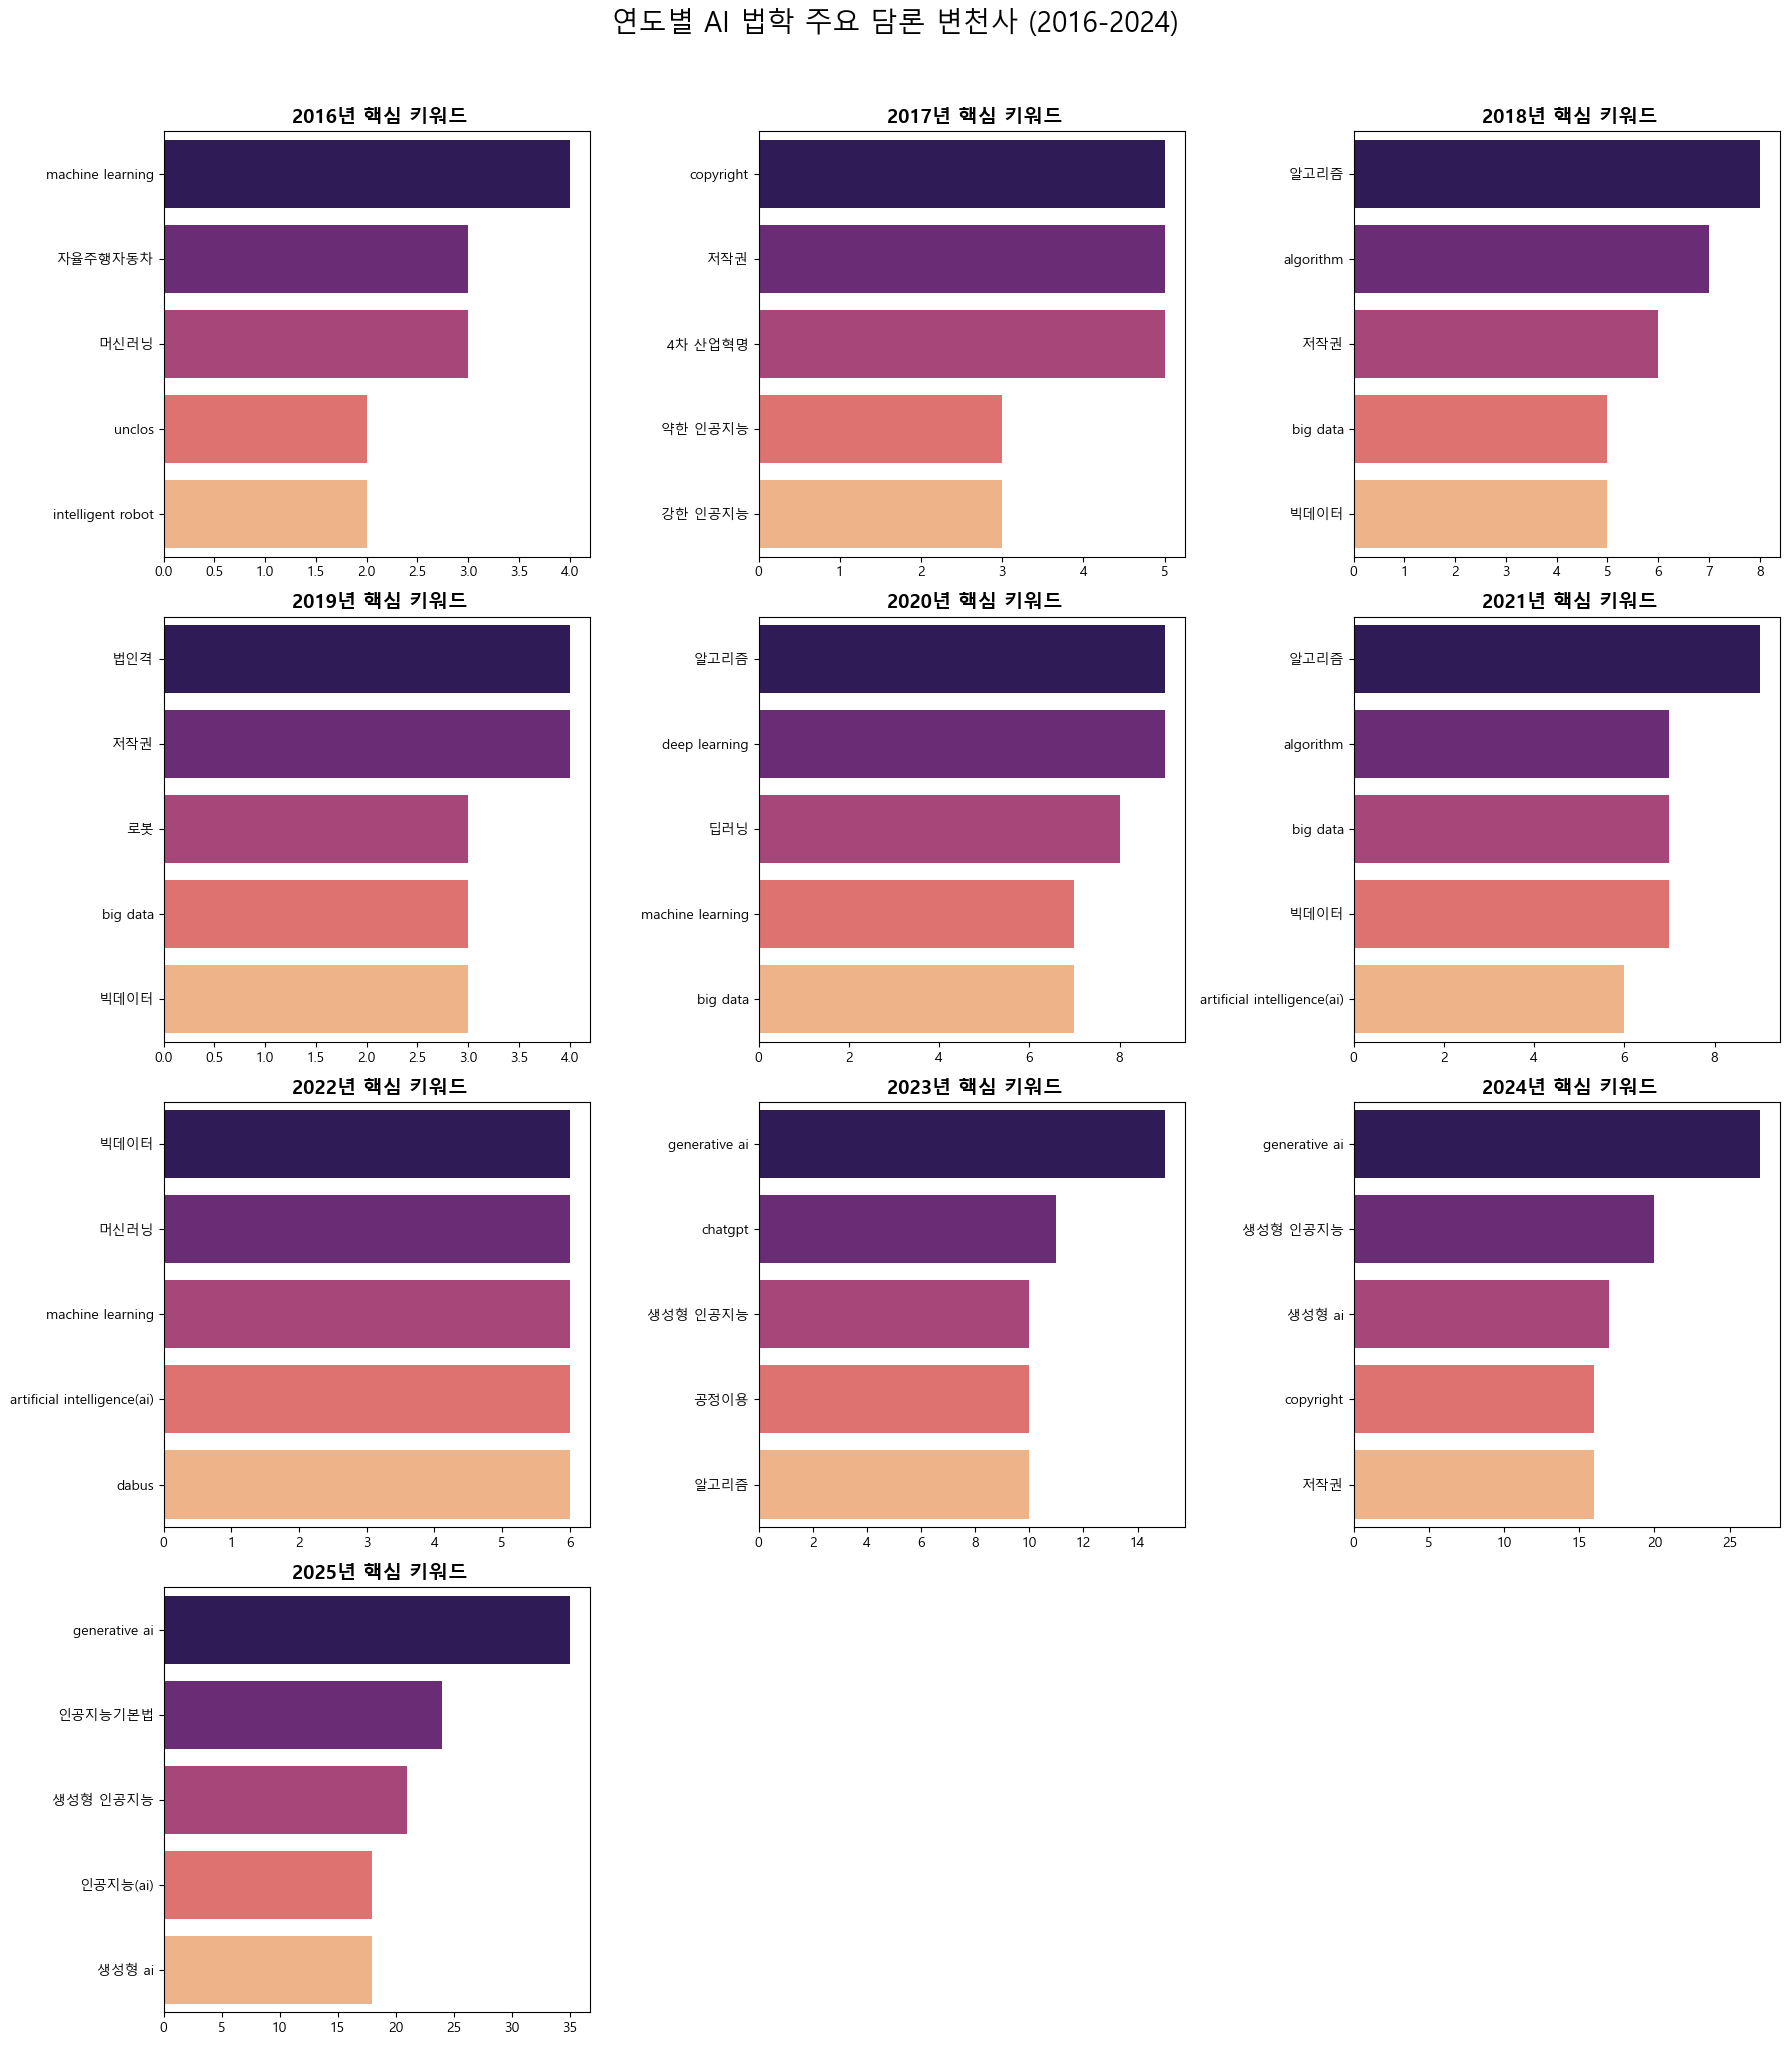

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import math

# 한글 폰트 설정
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

def analyze_yearly_top_keywords(file_path):
    # 1. 데이터 로드 및 전처리
    df = pd.read_csv(file_path)
    df = df[df['출판연도'] >= 2016] # 2016년 이후 필터링
    unique_papers = df.drop_duplicates(subset=['source_id']).copy()
    
    def clean_kw(kw_str):
        if pd.isna(kw_str): 
            return []
        
        # 1. ']]>' 제거 및 쉼표 분리
        words = str(kw_str).replace(']]>', '').split(',')
        
        # 2. 세척 및 소문자화 (Lowercasing)
        # strip()으로 공백을 지우고, lower()로 모두 소문자로 변환합니다.
        cleaned = [w.strip().lower() for w in words if w.strip()]
        
        # 3. 불용어 리스트 (비교를 위해 모두 소문자로 작성)
        stopwords = ['인공지능', 'ai', 'artificial intelligence', 'law', 'legal']
        
        # 4. 불용어에 해당하지 않는 단어만 반환
        return [w for w in cleaned if w not in stopwords]
    
    unique_papers['cleaned_keywords'] = unique_papers['키워드'].apply(clean_kw)

    # 2. 연도별 Top 5 추출
    years = sorted(unique_papers['출판연도'].unique())
    num_years = len(years) # 실제 연도 개수 확인 (예: 10개)
    
    yearly_top_data = []
    for year in years:
        year_kws = unique_papers[unique_papers['출판연도'] == year]['cleaned_keywords'].sum()
        top_5 = Counter(year_kws).most_common(5)
        for rank, (word, freq) in enumerate(top_5, 1):
            yearly_top_data.append({'연도': int(year), '순위': rank, '키워드': word, '빈도': freq})

    result_df = pd.DataFrame(yearly_top_data)
    result_df.to_csv('연도별_핵심_키워드_Top5.csv', index=False, encoding='utf-8-sig')

    # 3. [해결!] 동적 subplot 생성 로직
    cols = 3 # 열 개수는 3개로 고정
    rows = math.ceil(num_years / cols) # 연도 개수에 따라 행 개수 자동 계산 (10개면 4행)

    fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 5)) # 행 수에 맞춰 높이 조절
    axes = axes.flatten() # 2차원 배열을 1차원으로 풀기

    for i, year in enumerate(years):
        year_data = result_df[result_df['연도'] == year]
        if not year_data.empty:
            sns.barplot(x='빈도', y='키워드', data=year_data, ax=axes[i], palette='magma')
            axes[i].set_title(f' {year}년 핵심 키워드', fontsize=14, fontweight='bold')
            axes[i].set_xlabel('')
            axes[i].set_ylabel('')

    # 남는 빈 칸(그래프가 그려지지 않은 axis) 안보이게 처리
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.suptitle('연도별 AI 법학 주요 담론 변천사 (2016-2024)', fontsize=20, y=1.02)
    plt.tight_layout()
    plt.savefig('연도별_핵심키워드_추이.png', dpi=300, bbox_inches='tight')
    plt.show()

# 실행
analyze_yearly_top_keywords('AI_논문_분야별_분류_최종.csv')

In [12]:
import pandas as pd
import os

def analyze_and_save_keyword_metrics(input_file, output_file='AI_법학_키워드_동태지표.csv'):
    # 1. 데이터 로드
    df = pd.read_csv(input_file)
    df = df[df['출판연도'] >= 2016]
    
    # [핵심] source_id 기반 중복 제거
    unique_papers = df.drop_duplicates(subset=['source_id']).copy()
    
    print(f"📊 중복 제거 전 데이터: {len(df)}건")
    print(f"✅ 중복 제거 후 고유 논문: {len(unique_papers)}건")

    # 2. 키워드 세척 함수 (소문자 통합 로직 추가)
    def clean_kw(kw_str):
        if pd.isna(kw_str): return []
        
        # ']]>' 제거 및 쉼표 분리
        raw_words = str(kw_str).replace(']]>', '').split(',')
        
        # [수정] 앞뒤 공백 제거 및 모두 소문자로 변환 (Case Normalization)
        cleaned = [w.strip().lower() for w in raw_words if w.strip()]
        
        # [수정] 불용어 리스트도 소문자로 구성하여 정확히 매칭되도록 함
        stopwords = ['인공지능', 'ai', 'artificial intelligence', 'artificial intelligence(ai)']
        
        return [w for w in cleaned if w not in stopwords]

    unique_papers['cleaned_keywords'] = unique_papers['키워드'].apply(clean_kw)

    # 3. 연도별 지표 계산
    years = sorted(unique_papers['출판연도'].unique())
    seen_keywords = set() # 누적 지식 저장소
    metrics_list = []

    for year in years:
        year_rows = unique_papers[unique_papers['출판연도'] == year]
        year_kws_all = year_rows['cleaned_keywords'].sum()
        
        # --- 지표 산출 ---
        tokens = len(year_kws_all)  # 전체 키워드 빈도 (소문자 통합 상태)
        types = len(set(year_kws_all))  # 고유 키워드 개수 (소문자 통합 상태)
        
        # TTR(Type-Token Ratio) 계산
        ttr = types / tokens if tokens > 0 else 0
        
        # 신규 키워드 산출 (과거에 등장하지 않았던 소문자 키워드 집합)
        current_year_unique = set(year_kws_all)
        new_kws = current_year_unique - seen_keywords
        new_kw_count = len(new_kws)
        
        # 결과 기록
        metrics_list.append({
            '연도': int(year),
            '고유논문수': len(year_rows),
            '전체키워드빈도(Tokens)': tokens,
            '고유키워드개수(Types)': types,
            '어휘다양성(TTR)': round(ttr, 4),
            '신규키워드수': new_kw_count
        })
        
        # 누적 저장소 업데이트
        seen_keywords.update(current_year_unique)

    # 4. CSV 저장
    metrics_df = pd.DataFrame(metrics_list)
    metrics_df.to_csv(output_file, index=False, encoding='utf-8-sig')
    
    print("-" * 50)
    print(f"🏁 분석 완료! 결과가 '{output_file}'에 저장되었습니다.")
    print(metrics_df.to_string(index=False))
    
    return metrics_df

# 실행
final_stats = analyze_and_save_keyword_metrics('AI_논문_분야별_분류_최종.csv')

📊 중복 제거 전 데이터: 1223건
✅ 중복 제거 후 고유 논문: 1223건
--------------------------------------------------
🏁 분석 완료! 결과가 'AI_법학_키워드_동태지표.csv'에 저장되었습니다.
  연도  고유논문수  전체키워드빈도(Tokens)  고유키워드개수(Types)  어휘다양성(TTR)  신규키워드수
2016     38              339             322      0.9499     322
2017     55              590             555      0.9407     527
2018     72              758             664      0.8760     565
2019     76              761             679      0.8922     571
2020    113             1246            1062      0.8523     862
2021    124             1268            1091      0.8604     850
2022    104             1091             934      0.8561     708
2023    152             1569            1277      0.8139     970
2024    212             2230            1707      0.7655    1244
2025    277             2968            2278      0.7675    1697


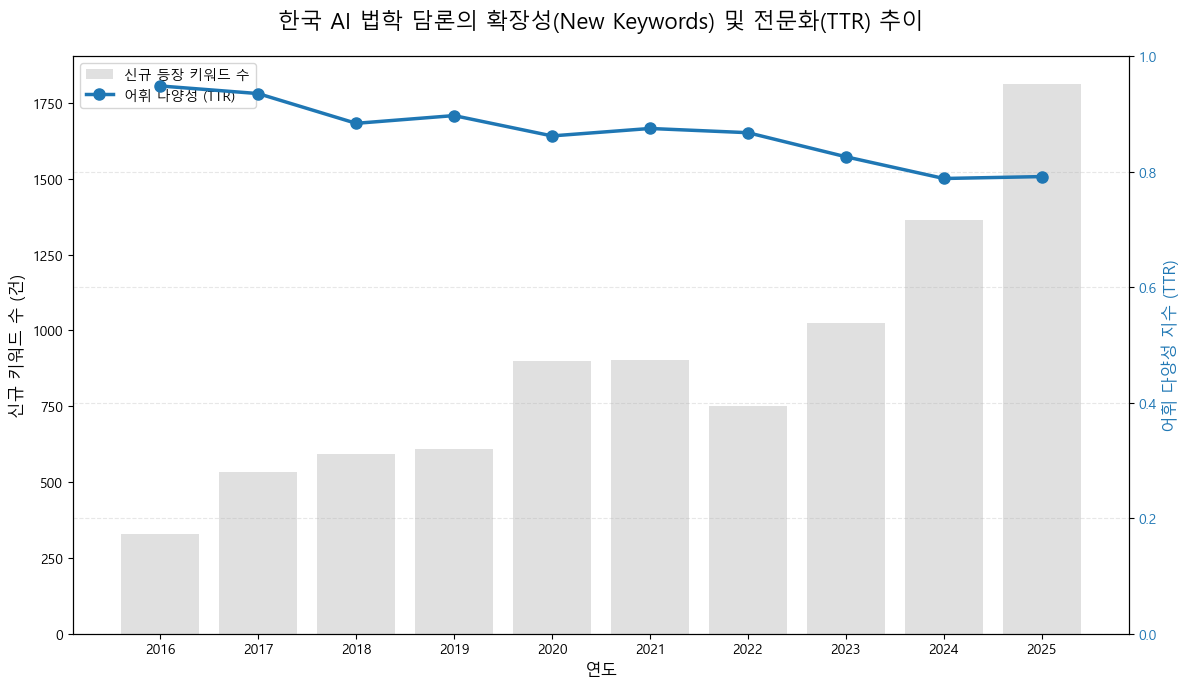

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Set font for Korean display
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

def plot_dual_axis_metrics(csv_file):
    df = pd.read_csv(csv_file)
    
    fig, ax1 = plt.subplots(figsize=(12, 7))

    # Bar chart for New Keywords (Left Y-axis)
    color_bar = '#D3D3D3'  # Light Gray
    bars = ax1.bar(df['연도'], df['신규키워드수'], color=color_bar, alpha=0.7, label='신규 등장 키워드 수')
    ax1.set_xlabel('연도', fontsize=12)
    ax1.set_ylabel('신규 키워드 수 (건)', fontsize=12)
    ax1.set_xticks(df['연도'])

    # Line chart for TTR (Right Y-axis)
    ax2 = ax1.twinx()
    color_line = '#1F77B4'  # Professional Blue
    line = ax2.plot(df['연도'], df['어휘다양성(TTR)'], color=color_line, marker='o', linewidth=2.5, markersize=8, label='어휘 다양성 (TTR)')
    ax2.set_ylabel('어휘 다양성 지수 (TTR)', fontsize=12, color=color_line)
    ax2.tick_params(axis='y', labelcolor=color_line)
    ax2.set_ylim(0, 1.0) # TTR is a ratio between 0 and 1

    # Adding legends
    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines + lines2, labels + labels2, loc='upper left', frameon=True)

    plt.title('한국 AI 법학 담론의 확장성(New Keywords) 및 전문화(TTR) 추이', fontsize=16, pad=20)
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('AI_법학_동태지표_혼합그래프.png', dpi=300)
    plt.show() # Not showing, just saving as per instructions

plot_dual_axis_metrics('AI_법학_키워드_동태지표.csv')

### 분류별 분석

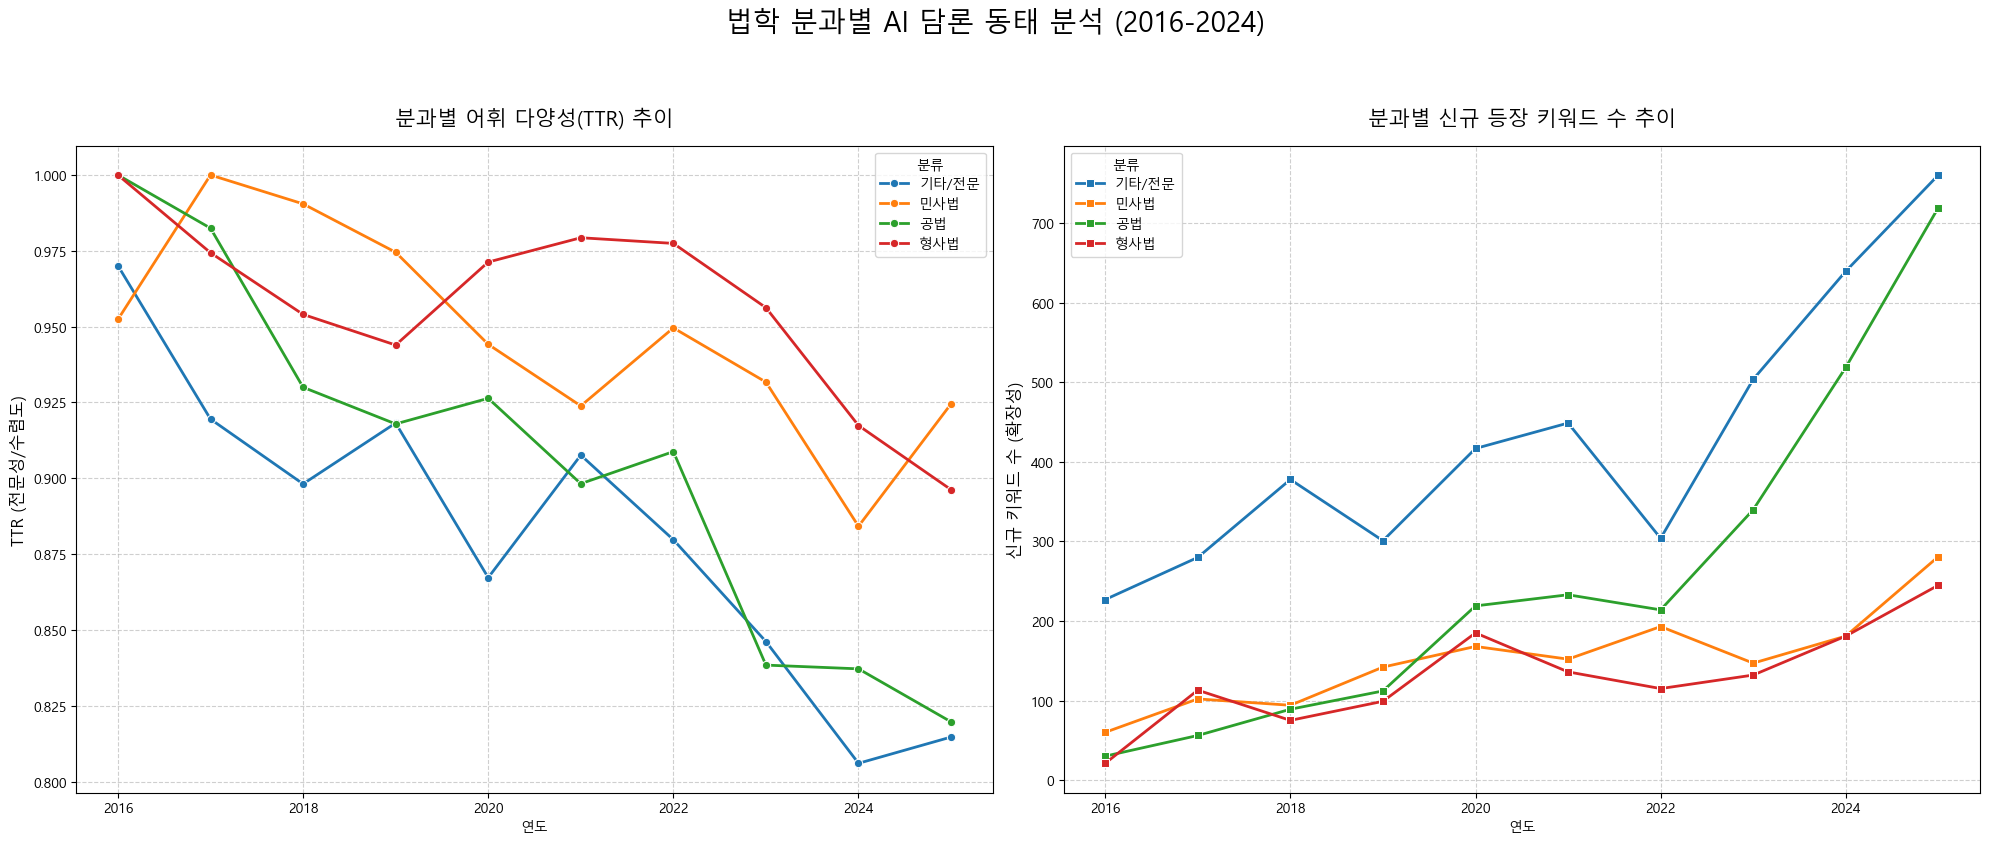

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 한글 폰트 설정
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

def analyze_by_category(input_file):
    # 1. 데이터 로드 및 전처리
    df = pd.read_csv(input_file)
    df = df[df['출판연도'] >= 2016]
    unique_papers = df.drop_duplicates(subset=['source_id']).copy()

    def clean_kw(kw_str):
        if pd.isna(kw_str): return []
        raw_words = str(kw_str).replace(']]>', '').split(',')
        cleaned = [w.strip() for w in raw_words if w.strip()]
        stopwords = ['인공지능', 'ai', 'artificial intelligence', 'artificial intelligence(ai)']
        return [w for w in cleaned if w not in stopwords]

    unique_papers['cleaned_keywords'] = unique_papers['키워드'].apply(clean_kw)

    # 2. 분야별/연도별 지표 계산
    categories = unique_papers['분류'].unique()
    years = sorted(unique_papers['출판연도'].unique())
    
    all_metrics = []
    
    # 분야별로 독립적인 '이미 등장한 키워드' 집합 관리
    category_seen_keywords = {cat: set() for cat in categories}

    for cat in categories:
        cat_df = unique_papers[unique_papers['분류'] == cat]
        
        for year in years:
            year_rows = cat_df[cat_df['출판연도'] == year]
            if len(year_rows) == 0:
                continue
                
            year_kws_all = year_rows['cleaned_keywords'].sum()
            
            # TTR 계산
            tokens = len(year_kws_all)
            types = len(set(year_kws_all))
            ttr = types / tokens if tokens > 0 else 0
            
            # 해당 분야 내 신규 키워드 산출
            current_year_unique = set(year_kws_all)
            new_kws = current_year_unique - category_seen_keywords[cat]
            new_kw_count = len(new_kws)
            
            # 지표 저장
            all_metrics.append({
                '분류': cat,
                '연도': int(year),
                'TTR': ttr,
                '신규키워드수': new_kw_count,
                '논문수': len(year_rows)
            })
            
            # 해당 분야의 누적 집합 업데이트
            category_seen_keywords[cat].update(current_year_unique)

    return pd.DataFrame(all_metrics)

def plot_category_metrics(metrics_df):
    # 시각화 설정: 1행 2열 (TTR 추이, 신규 키워드 추이)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

    # 1. 분야별 어휘 다양성(TTR) 추이
    sns.lineplot(data=metrics_df, x='연도', y='TTR', hue='분류', marker='o', ax=ax1, linewidth=2)
    ax1.set_title('분과별 어휘 다양성(TTR) 추이', fontsize=15, pad=15)
    ax1.set_ylabel('TTR (전문성/수렴도)', fontsize=12)
    ax1.grid(True, linestyle='--', alpha=0.6)

    # 2. 분야별 신규 등장 키워드 수 추이
    sns.lineplot(data=metrics_df, x='연도', y='신규키워드수', hue='분류', marker='s', ax=ax2, linewidth=2)
    ax2.set_title('분과별 신규 등장 키워드 수 추이', fontsize=15, pad=15)
    ax2.set_ylabel('신규 키워드 수 (확장성)', fontsize=12)
    ax2.grid(True, linestyle='--', alpha=0.6)

    plt.suptitle('법학 분과별 AI 담론 동태 분석 (2016-2024)', fontsize=20, y=1.05)
    plt.tight_layout()
    plt.savefig('분과별_키워드_동태분석.png', dpi=300, bbox_inches='tight')
    plt.show()

# 실행
metrics_by_cat = analyze_by_category('AI_논문_분야별_분류_최종.csv')
plot_category_metrics(metrics_by_cat)

### 연도 추세분석

📈 2015-2024 AI 법학 연평균 성장률(CAGR): 23.97%
      전체_법학_논문수  AI_논문수  AI_비중(%)
2016       4445    38.0  0.854893
2017       4453    55.0  1.235122
2018       4273    72.0  1.684999
2019       4418    76.0  1.720235
2020       4583   113.0  2.465634
2021       4541   124.0  2.730676
2022       4631   104.0  2.245735
2023       4651   152.0  3.268114
2024       4695   212.0  4.515442


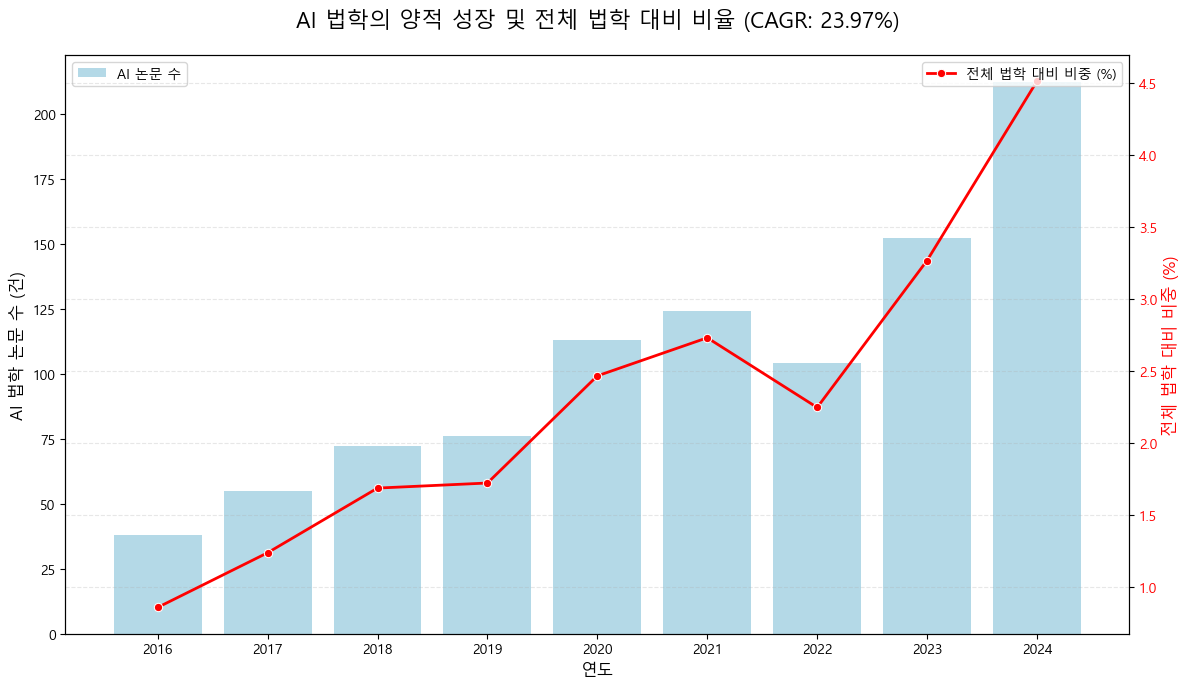

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 한글 폰트 설정 (Windows 기준)
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

def analyze_growth_and_ratio(ai_file, total_file):
    # 1. 데이터 로드
    df_ai = pd.read_csv(ai_file)
    df_total = pd.read_csv(total_file)
    
    # 2. 연도별 집계 (2015-2024 범위 한정)
    # AI 논문 수 계산
    ai_counts = df_ai.groupby('출판연도').size().rename('AI_논문수')
    
    # 전체 법학 논문 수 계산 ('발행연도' 컬럼 기준)
    total_counts = df_total.groupby('발행연도').size().rename('전체_법학_논문수')
    
    # 두 데이터 합치기
    stats = pd.concat([total_counts, ai_counts], axis=1).fillna(0)
    stats = stats.loc[2016:2024] # 분석 기간 설정
    
    # 3. 지표 계산
    # (1) 전체 대비 비중 (%)
    stats['AI_비중(%)'] = (stats['AI_논문수'] / stats['전체_법학_논문수']) * 100
    
    # (2) 연평균 성장률(CAGR) 계산
    # 공식: (끝값 / 시작값) ^ (1 / 기간) - 1
    begin_val = stats['AI_논문수'].iloc[0]
    end_val = stats['AI_논문수'].iloc[-1]
    n_years = len(stats) - 1
    cagr = (end_val / begin_val)**(1 / n_years) - 1
    
    print(f"📈 2015-2024 AI 법학 연평균 성장률(CAGR): {cagr:.2%}")
    print(stats[['전체_법학_논문수', 'AI_논문수', 'AI_비중(%)']])

    # 4. 시각화 (이중 축 그래프)
    fig, ax1 = plt.subplots(figsize=(12, 7))
    
    # 축 1: AI 논문 수 (막대 그래프)
    sns.barplot(x=stats.index, y=stats['AI_논문수'], ax=ax1, color='skyblue', alpha=0.7, label='AI 논문 수')
    ax1.set_ylabel('AI 법학 논문 수 (건)', fontsize=12)
    ax1.set_xlabel('연도', fontsize=12)
    
    # 축 2: 비중 (꺾은선 그래프)
    ax2 = ax1.twinx()
    sns.lineplot(x=np.arange(len(stats)), y=stats['AI_비중(%)'], ax=ax2, color='red', marker='o', linewidth=2, label='전체 법학 대비 비중 (%)')
    ax2.set_ylabel('전체 법학 대비 비중 (%)', fontsize=12, color='red')
    ax2.tick_params(axis='y', labelcolor='red')

    # 타이틀 및 범례
    plt.title(f'AI 법학의 양적 성장 및 전체 법학 대비 비율 (CAGR: {cagr:.2%})', fontsize=16, pad=20)
    ax1.legend(loc='upper left')
    ax2.legend(loc='upper right')
    
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.savefig('AI법학_성장성_및_비중분석.png', dpi=300)
    plt.show()

analyze_growth_and_ratio('AI_논문_분야별_분류_최종.csv', '전체_법학_논문목록_정제본.csv')

전처리 및 가상ID 처리

In [ ]:
import pandas as pd
from tqdm import tqdm

def run_kci_only_ai_preprocessing(node_file, edge_file):
    print("1/4. 데이터 로드 및 AI 시드(Seed) 논문 필터링...")
    df_nodes = pd.read_csv(node_file)
    
    # [조건] 2015년 이후 발간 & 제목 또는 초록에 키워드 포함
    # AI는 대문자만, 나머지는 대소문자 무관
    ai_pattern = r'AI|(?i:Artificial Intelligence|인공지능)'

    # mask_ai = (df_nodes['발행연도'] >= 2015) & (
    #     # 여기서 case=True로 설정해야 패턴 내의 개별 설정이 작동합니다.
    #     df_nodes['제목'].str.contains(ai_pattern, case=True, na=False) | 
    #     df_nodes['초록'].str.contains(ai_pattern, case=True, na=False)
    # )
    mask_ai = (
        # 여기서 case=True로 설정해야 패턴 내의 개별 설정이 작동합니다.
        df_nodes['제목'].str.contains(ai_pattern, case=True, na=False) | 
        df_nodes['초록'].str.contains(ai_pattern, case=True, na=False)
    )
    ai_seed_df = df_nodes[mask_ai].copy()
    ai_seed_ids = set(ai_seed_df['논문ID'].unique())
    all_kci_ids = set(df_nodes['논문ID'].unique()) # 전체 KCI 논문 ID 집합
    
    print(f"   -> AI 시드 논문 선정: {len(ai_seed_ids)}편")

    print("2/4. 인용 엣지 필터링 (KCI to KCI)...")
    df_edges = pd.read_csv(edge_file)
    
    # 필터링 규칙:
    # 1. 인용을 한 논문(source_id)이 AI 시드 논문이어야 함
    # 2. 인용을 당한 논문(target_arti_id)이 KCI ID를 가지고 있어야 함
    # 3. 그 target_arti_id가 실제로 노드 리스트(KCI)에 존재해야 함
    
    mask_kci_to_kci = (
        df_edges['source_id'].isin(ai_seed_ids) & 
        df_edges['target_arti_id'].notna() & 
        df_edges['target_arti_id'].isin(all_kci_ids)
    )
    
    final_edges = df_edges[mask_kci_to_kci].copy()
    # 컬럼명 통일
    final_edges = final_edges.rename(columns={'target_arti_id': 'target_id_final'})
    
    print(f"   -> 필터링된 KCI 간 인용 관계 수: {len(final_edges)}")

    print("3/4. 최종 분석 대상 노드 리스트 정리...")
    # 엣지에 등장하는 모든 논문 ID (Source + Target)|
    active_node_ids = set(final_edges['source_id'].unique()) | set(final_edges['target_id_final'].unique())
    
    # 노드 메타데이터 추출
    final_nodes = df_nodes[df_nodes['논문ID'].isin(active_node_ids)].copy()
    final_nodes = final_nodes.rename(columns={'논문ID': 'node_id'})
    
    print("4/4. KCI 전용 AI 데이터 저장 중...")
    # 최종 결과물 저장
    final_edges[['source_id', 'target_id_final', 'ref_type']].to_csv('KCI_AI_전용_인용_엣지.csv', index=False, encoding='utf-8-sig')
    final_nodes[['node_id', '발행연도', '제목', '저자', '학술지명']].to_csv('KCI_AI_전용_논문_노드.csv', index=False, encoding='utf-8-sig')

    print(f"\n✅ KCI 전용 정제 완료!")
    print(f"- 최종 노드 수: {len(final_nodes)}개")
    print(f"- 최종 엣지 수: {len(final_edges)}개")

if __name__ == "__main__":
    run_kci_only_ai_preprocessing('전체_법학_논문목록_정제본.csv', '법학_인용_네트워크_데이터_전체.csv')

In [ ]:
# 최종 정제된 노드 파일 로드
final_nodes = pd.read_csv('KCI_AI_전용_논문_노드.csv')

# 발행연도별 분포 확인
year_dist = final_nodes['발행연도'].value_counts().sort_index()
print("📊 최종 데이터에 포함된 논문의 발행연도 분포:")
print(year_dist.head(10)) # 아주 오래된 논문들도 포함되어 있을 것입니다.

# 2015년 이전 논문 비중 계산
pre_2015 = final_nodes[final_nodes['발행연도'] < 2015]
print(f"\n💡 2015년 이전 발행된 논문 수: {len(pre_2015)}개")

# 분절분석

In [3]:
import pandas as pd
import networkx as nx
from tqdm import tqdm

# 1. 데이터 로드
df_nodes = pd.read_csv('KCI_AI_전용_논문_노드.csv')
df_edges = pd.read_csv('KCI_AI_전용_인용_엣지.csv')

# 2. 분석을 위해 엣지 데이터에 Source 논문의 발행연도 매칭
df_edges = df_edges.merge(df_nodes[['node_id', '발행연도']], left_on='source_id', right_on='node_id', how='left')

def analyze_discrete_network(start_year=2015, end_year=2024):
    yearly_metrics = []
    
    for year in tqdm(range(start_year, end_year + 1), desc="연도별 지표 계산 중"):
        # --- [추가 코드] 해당 연도에 실제로 '발행'된 논문 숫자 계산 ---
        num_papers_published = len(df_nodes[df_nodes['발행연도'] == year])
        
        # 해당 연도에 발행된 논문들이 생성한 엣지만 추출
        year_edges = df_edges[df_edges['발행연도'] == year]
        
        if year_edges.empty:
            # 엣지가 없더라도 발행 논문 수는 기록하기 위해 처리
            yearly_metrics.append({
                '연도': year,
                '발행논문수': num_papers_published,
                '네트워크_노드수': 0,
                '엣지수': 0,
                '밀도': 0,
                '주요논문': "데이터 없음"
            })
            continue
            
        # 그래프 생성
        G = nx.DiGraph()
        G.add_edges_from(zip(year_edges['source_id'], year_edges['target_id_final']))
        
        # 지표 계산
        num_nodes = G.number_of_nodes() # 네트워크에 포함된 논문 수 (인용한 논문 + 인용된 논문)
        num_edges = G.number_of_edges()
        density = nx.density(G)
        
        # 인차수(In-degree) 상위 논문 추출
        in_degrees = dict(G.in_degree())
        top_nodes = sorted(in_degrees.items(), key=lambda x: x[1], reverse=True)[:3]
        
        top_titles = []
        for node_id, count in top_nodes:
            title_info = df_nodes[df_nodes['node_id'] == node_id]['제목']
            title = title_info.values[0] if not title_info.empty else "Unknown"
            top_titles.append(f"{title}({count}회)")
            
        yearly_metrics.append({
            '연도': year,
            '발행논문수': num_papers_published,  # 추가된 지표
            '네트워크_노드수': num_nodes,
            '엣지수': num_edges,
            '밀도': round(density, 5),
            '주요논문': ", ".join(top_titles)
        })
        
    return pd.DataFrame(yearly_metrics)

# 분석 실행
discrete_results = analyze_discrete_network()
discrete_results.to_csv('연도별_분절분석_결과.csv', index=False, encoding='utf-8-sig')

print("\n📊 연도별 주요 지표 요약 (발행논문수 포함):")
print(discrete_results[['연도', '발행논문수', '네트워크_노드수', '엣지수', '밀도']])

FileNotFoundError: [Errno 2] No such file or directory: 'KCI_AI_전용_논문_노드.csv'

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. 분석 결과 데이터 로드
df = pd.read_csv('연도별_분절분석_결과.csv')

# 2. 시각화 (이중 축 활용)
fig, ax1 = plt.subplots(figsize=(12, 7))

# 축 1: 발행논문수 및 네트워크 노드수 (Bar)
# 두 데이터를 나란히 보여주기 위해 바 차트를 겹치거나 나열할 수 있습니다.
ax1.bar(df['연도'] - 0.2, df['발행논문수'], width=0.4, color='lightgray', alpha=0.7, label='Published AI Papers')
ax1.bar(df['연도'] + 0.2, df['네트워크_노드수'], width=0.4, color='skyblue', alpha=0.6, label='Nodes in Network (Citing/Cited)')

# 축 1: 엣지수 (Line) - 인용 관계의 총량
ax1.plot(df['연도'], df['엣지수'], color='steelblue', marker='o', linewidth=2, label='Edges (Citations)')

ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Count (Papers/Citations)', fontsize=12)
ax1.set_xticks(df['연도'])
ax1.legend(loc='upper left')

# 축 2: 밀도 (Secondary Y-axis)
ax2 = ax1.twinx()
ax2.plot(df['연도'], df['밀도'], color='tab:red', marker='s', linestyle='--', label='Network Density')
ax2.set_ylabel('Network Density', color='tab:red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='tab:red')
ax2.legend(loc='upper right')

# 그래프 제목 및 설정
plt.title('Growth and Structural Evolution of AI Law Research (2015-2024)', fontsize=14, pad=20)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 레이아웃 조정 및 저장
plt.tight_layout()
plt.savefig('AI_law_discrete_trends_updated.png', dpi=300)
plt.show()

###

# 개별 분석 시작

## 발행연도 상관 없이 특정 연도까지 인용된 모든 논문

In [ ]:
import pandas as pd
import networkx as nx
import community.community_louvain as louvain
import os
from tqdm import tqdm
from collections import Counter

# 1. 환경 설정
OUTPUT_DIR = '01_AI_누적_지식_기반_분석'
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

# 2. 데이터 로드
print("데이터를 로드하는 중...")
# 데이터 파일명은 사용자님의 파일 환경에 맞춰 'KCI_AI_전용_논문_노드.csv' 등으로 수정 가능합니다.
nodes = pd.read_csv('KCI_AI_전용_논문_노드.csv')
edges = pd.read_csv('KCI_AI_전용_인용_엣지.csv')

# 엣지에 발행연도 매칭 (Source 논문의 발행연도를 기준으로 누적 범위를 결정)
# 주의: 이 merge는 인용을 '한' 논문의 연도를 붙이는 작업입니다.
edges_with_year = edges.merge(nodes[['node_id', '발행연도']], left_on='source_id', right_on='node_id', how='left')

def run_cumulative_intellectual_base_tracking(start_year=2015, end_year=2024):
    for year in tqdm(range(start_year, end_year + 1), desc="연도별 누적 분석 진행 중"):
        # [핵심 로직] 기준 연도(year) 이하에 발행된 논문들이 생성한 모든 엣지 추출
        # 2015년 이전의 인용 기록이 edges에 있다면, 이 필터링을 통해 과거의 권위가 합산됩니다.
        cum_edges = edges_with_year[edges_with_year['발행연도'] <= year]
        
        if cum_edges.empty:
            continue
            
        # 그래프 생성
        G_dir = nx.DiGraph()
        G_dir.add_edges_from(zip(cum_edges['source_id'], cum_edges['target_id_final']))
        
        # 커뮤니티 탐지 (Louvain은 비방향 그래프 기준)
        G_undir = G_dir.to_undirected()
        partition = louvain.best_partition(G_undir)
        
        # 지표 계산
        comm_counts = Counter(partition.values())
        top_5_communities = [comm[0] for comm in comm_counts.most_common(5)]
        in_degrees = dict(G_dir.in_degree())
        
        year_data = []
        for comm_rank, comm_id in enumerate(top_5_communities, 1):
            # 해당 커뮤니티 소속 노드 추출
            comm_nodes = [n for n, c in partition.items() if c == comm_id]
            
            # 커뮤니티 내 논문들을 피인용수(In-degree) 기준으로 정렬
            comm_papers_sorted = sorted(
                [(n, in_degrees.get(n, 0)) for n in comm_nodes],
                key=lambda x: x[1],
                reverse=True
            )[:5]
            
            for paper_rank, (node_id, citation_count) in enumerate(comm_papers_sorted, 1):
                paper_info = nodes[nodes['node_id'] == node_id]
                if not paper_info.empty:
                    year_data.append({
                        '커뮤니티_순위': comm_rank,
                        '커뮤니티_ID': comm_id,
                        '커뮤니티_크기': comm_counts[comm_id],
                        '논문_순위': paper_rank,
                        '인용수': citation_count,
                        '제목': paper_info['제목'].values[0],
                        '저자': paper_info['저자'].values[0],
                        '발행연도': paper_info['발행연도'].values[0],
                        'node_id': node_id
                    })
        
        # 결과 저장
        if year_data:
            year_df = pd.DataFrame(year_data)
            file_path = os.path.join(OUTPUT_DIR, f"cumulative_{year}.csv")
            year_df.to_csv(file_path, index=False, encoding='utf-8-sig')

if __name__ == "__main__":
    run_cumulative_intellectual_base_tracking()
    print(f"\n✅ 누적 지식 기반 분석 완료! '{OUTPUT_DIR}' 폴더를 확인하세요.")

## 발행연도 상관 없이 특정 연도에 인용된 모든 논문

In [ ]:
import pandas as pd
import networkx as nx
import community.community_louvain as louvain
import os
from tqdm import tqdm
from collections import Counter

# 1. 환경 설정
OUTPUT_DIR = '02_AI_시점별_담론_지형_분석'
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

# 2. 데이터 로드
print("데이터를 로드하는 중...")
nodes = pd.read_csv('KCI_AI_전용_논문_노드.csv')
edges = pd.read_csv('KCI_AI_전용_인용_엣지.csv')

# 엣지에 발행연도 매칭 (인용을 수행한 Source 논문의 발행연도 기준)
edges_with_year = edges.merge(nodes[['node_id', '발행연도']], left_on='source_id', right_on='node_id', how='left')

def run_snapshot_discourse_tracking(start_year=2015, end_year=2024):
    for year in tqdm(range(start_year, end_year + 1), desc="연도별 스냅샷 분석 진행 중"):
        # [핵심 로직] 오직 해당 연도(year)에 발행된 논문들이 생성한 엣지만 추출
        # 이 필터링을 통해 '그해의 연구자들이 선택한 지식'만 남게 됩니다.
        snapshot_edges = edges_with_year[edges_with_year['발행연도'] == year]
        
        if snapshot_edges.empty:
            continue
            
        # 그래프 생성
        G_dir = nx.DiGraph()
        G_dir.add_edges_from(zip(snapshot_edges['source_id'], snapshot_edges['target_id_final']))
        
        # 커뮤니티 탐지 (Louvain)
        G_undir = G_dir.to_undirected()
        partition = louvain.best_partition(G_undir)
        
        # 지표 계산
        comm_counts = Counter(partition.values())
        top_5_communities = [comm[0] for comm in comm_counts.most_common(5)]
        in_degrees = dict(G_dir.in_degree())
        
        year_data = []
        for comm_rank, comm_id in enumerate(top_5_communities, 1):
            comm_nodes = [n for n, c in partition.items() if c == comm_id]
            
            # 당해 연도 피인용수 기준으로 정렬 (해당 시점의 인기 논문 식별)
            comm_papers_sorted = sorted(
                [(n, in_degrees.get(n, 0)) for n in comm_nodes],
                key=lambda x: x[1],
                reverse=True
            )[:5]
            
            for paper_rank, (node_id, citation_count) in enumerate(comm_papers_sorted, 1):
                paper_info = nodes[nodes['node_id'] == node_id]
                if not paper_info.empty:
                    year_data.append({
                        '커뮤니티_순위': comm_rank,
                        '커뮤니티_ID': comm_id,
                        '커뮤니티_크기': comm_counts[comm_id],
                        '논문_순위': paper_rank,
                        '인용수(당해)': citation_count,
                        '제목': paper_info['제목'].values[0],
                        '저자': paper_info['저자'].values[0],
                        '원래_발행연도': paper_info['발행연도'].values[0],
                        'node_id': node_id
                    })
        
        # 결과 저장
        if year_data:
            year_df = pd.DataFrame(year_data)
            file_path = os.path.join(OUTPUT_DIR, f"snapshot_{year}.csv")
            year_df.to_csv(file_path, index=False, encoding='utf-8-sig')

if __name__ == "__main__":
    run_snapshot_discourse_tracking()
    print(f"\n 시점별 담론 분석 완료! '{OUTPUT_DIR}' 폴더를 확인하세요.")

## 특정 연도에 발행한 논문의 중 피인용 횟수 기준

In [ ]:
import pandas as pd
import networkx as nx
import community.community_louvain as louvain
import os
from tqdm import tqdm
from collections import Counter

# 1. 환경 설정
OUTPUT_DIR = '03_AI_연도별_신성_담론_분석'
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

# 2. 데이터 로드
print("데이터를 로드하는 중...")
nodes = pd.read_csv('KCI_AI_전용_논문_노드.csv')
edges = pd.read_csv('KCI_AI_전용_인용_엣지.csv')

def run_rising_star_paper_tracking(start_year=2015, end_year=2024):
    print("전체 기간 통합 네트워크 분석 중 (지식 구조 식별)...")
    # [핵심 로직] 전체 기간의 엣지를 사용하여 '글로벌 위상'과 '글로벌 커뮤니티'를 먼저 계산합니다.
    G_total = nx.DiGraph()
    G_total.add_edges_from(zip(edges['source_id'], edges['target_id_final']))
    
    # 1. 전체 네트워크에서의 피인용수(Global In-degree) 계산
    global_in_degrees = dict(G_total.in_degree())
    
    # 2. 전체 네트워크에서의 커뮤니티 탐지 (지식의 거대한 줄기 파악)
    G_undir = G_total.to_undirected()
    global_partition = louvain.best_partition(G_undir)
    global_comm_counts = Counter(global_partition.values())

    for year in tqdm(range(start_year, end_year + 1), desc="연도별 발행작 분석 진행 중"):
        # [핵심 로직] 오직 해당 연도(year)에 '발행된' 논문들만 추출
        year_born_papers = nodes[nodes['발행연도'] == year].copy()
        
        if year_born_papers.empty:
            continue
            
        # 글로벌 지표 결합
        year_born_papers['인용수_전체'] = year_born_papers['node_id'].map(global_in_degrees).fillna(0)
        year_born_papers['커뮤니티_ID'] = year_born_papers['node_id'].map(global_partition)
        
        # 해당 연도 발행작들이 기여하고 있는 상위 5개 글로벌 커뮤니티 식별
        top_5_comms = year_born_papers['커뮤니티_ID'].value_counts().head(5).index
        
        year_data = []
        for comm_rank, comm_id in enumerate(top_5_comms, 1):
            # 해당 연도 발행 + 특정 커뮤니티 소속 논문 필터링
            comm_papers = year_born_papers[year_born_papers['커뮤니티_ID'] == comm_id]
            
            # 전체 피인용수 기준으로 정렬 (미래의 고전이 될 논문 식별)
            top_5_papers = comm_papers.sort_values(by='인용수_전체', ascending=False).head(5)
            
            for paper_rank, (_, row) in enumerate(top_5_papers.iterrows(), 1):
                year_data.append({
                    '커뮤니티_순위': comm_rank,
                    '커뮤니티_ID': comm_id,
                    '커뮤니티_전체크기': global_comm_counts[comm_id],
                    '논문_순위': paper_rank,
                    '누적_인용수': row['인용수_전체'],
                    '제목': row['제목'],
                    '저자': row['저자'],
                    '발행연도': year, # 파일 내 확인용
                    'node_id': row['node_id']
                })
        
        # 결과 저장
        if year_data:
            year_df = pd.DataFrame(year_data)
            file_path = os.path.join(OUTPUT_DIR, f"rising_stars_{year}.csv")
            year_df.to_csv(file_path, index=False, encoding='utf-8-sig')

if __name__ == "__main__":
    run_rising_star_paper_tracking()
    print(f"\n 연도별 신성 담론 분석 완료! '{OUTPUT_DIR}' 폴더를 확인하세요.")

## 특정 연도에 발행한 논문의 중 피인용 횟수 기준 2년 이내

In [ ]:
import pandas as pd
import networkx as nx
import community.community_louvain as louvain
import os
from tqdm import tqdm
from collections import Counter

# 1. 환경 설정
OUTPUT_DIR = '04_AI_최신_연구_전선_분석'
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

# 2. 데이터 로드
print("데이터를 로드하는 중...")
nodes = pd.read_csv('KCI_AI_전용_논문_노드.csv')
edges = pd.read_csv('KCI_AI_전용_인용_엣지.csv')

# 엣지에 Source(인용한 논문)와 Target(인용된 논문)의 발행연도를 모두 매칭
# 1. Source 연도 매칭
edges_meta = edges.merge(nodes[['node_id', '발행연도']], left_on='source_id', right_on='node_id', how='left')
edges_meta = edges_meta.rename(columns={'발행연도': 'source_year'})

# 2. Target 연도 매칭
edges_meta = edges_meta.merge(nodes[['node_id', '발행연도']], left_on='target_id_final', right_on='node_id', how='left')
edges_meta = edges_meta.rename(columns={'발행연도': 'target_year'})

def run_research_front_tracking(start_year=2015, end_year=2024):
    for year in tqdm(range(start_year, end_year + 1), desc="연구 전선 분석 진행 중"):
        # [핵심 로직] 
        # 1. 인용 대상(Target)이 분석 연도(year)에 발행된 논문이어야 함
        # 2. 인용한 논문(Source)이 발행 연도부터 +1년(year+1) 사이에 발행되어야 함
        mask_front = (edges_meta['target_year'] == year) & \
                     (edges_meta['source_year'] >= year) & \
                     (edges_meta['source_year'] <= year + 1)
        
        front_edges = edges_meta[mask_front]
        
        if front_edges.empty:
            continue
            
        # 그래프 생성
        G_dir = nx.DiGraph()
        G_dir.add_edges_from(zip(front_edges['source_id'], front_edges['target_id_final']))
        
        # 커뮤니티 탐지 (Louvain)
        G_undir = G_dir.to_undirected()
        partition = louvain.best_partition(G_undir)
        
        # 지표 계산
        comm_counts = Counter(partition.values())
        top_5_communities = [comm[0] for comm in comm_counts.most_common(5)]
        in_degrees = dict(G_dir.in_degree())
        
        year_data = []
        for comm_rank, comm_id in enumerate(top_5_communities, 1):
            comm_nodes = [n for n, c in partition.items() if c == comm_id]
            
            # 단기 피인용수 기준으로 정렬 (초기 파급력이 강한 논문 식별)
            comm_papers_sorted = sorted(
                [(n, in_degrees.get(n, 0)) for n in comm_nodes],
                key=lambda x: x[1],
                reverse=True
            )[:5]
            
            for paper_rank, (node_id, citation_count) in enumerate(comm_papers_sorted, 1):
                paper_info = nodes[nodes['node_id'] == node_id]
                if not paper_info.empty:
                    year_data.append({
                        '커뮤니티_순위': comm_rank,
                        '커뮤니티_ID': comm_id,
                        '커뮤니티_크기': comm_counts[comm_id],
                        '논문_순위': paper_rank,
                        '단기_인용수(2년)': citation_count,
                        '제목': paper_info['제목'].values[0],
                        '저자': paper_info['저자'].values[0],
                        '발행연도': year,
                        'node_id': node_id
                    })
        
        # 결과 저장
        if year_data:
            year_df = pd.DataFrame(year_data)
            file_path = os.path.join(OUTPUT_DIR, f"research_front_{year}.csv")
            year_df.to_csv(file_path, index=False, encoding='utf-8-sig')

if __name__ == "__main__":
    run_research_front_tracking()
    print(f"\n✅ 최신 연구 전선 분석 완료! '{OUTPUT_DIR}' 폴더를 확인하세요.")

### 엑셀 컴바인

In [ ]:
import pandas as pd
import os

# 1. CSV 파일들이 있는 폴더 경로 설정
folder_path = './04_AI_최신_연구_전선_분석'  # CSV 파일이 저장된 폴더명으로 수정하세요
output_file = '04_AI_최신_연구_전선_분석결과.xlsx'

# 2. ExcelWriter 객체 생성
with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
    # 폴더 내의 모든 파일 확인
    for file_name in os.listdir(folder_path):
        if file_name.endswith('.csv'):
            # 파일 경로 생성
            file_path = os.path.join(folder_path, file_name)
            
            # CSV 읽기 (인코딩 문제는 필요시 encoding='cp949' 추가)
            df = pd.read_csv(file_path)
            
            # 시트 이름 설정 (파일명에서 .csv 제외, 최대 31자 제한 준수)
            sheet_name = file_name[:-4][:31]
            
            # 엑셀 시트로 쓰기
            df.to_excel(writer, sheet_name=sheet_name, index=False)

print(f"합치기 완료! 생성된 파일: {output_file}")

### MPA 분석

In [ ]:
import pandas as pd
import networkx as nx
import time

# 1. 데이터 로드
print("1/5. 데이터 로딩 중...")
nodes = pd.read_csv('KCI_AI_전용_논문_노드.csv')
edges = pd.read_csv('KCI_AI_전용_인용_엣지.csv')

# --- [추가] 연도 범위 설정 라인 ---
start_year = 2015  # 시작 연도
end_year = 2024    # 종료 연도

# 설정한 범위에 해당하는 노드만 필터링
nodes = nodes[(nodes['발행연도'] >= start_year) & (nodes['발행연도'] <= end_year)]

# 필터링된 노드들에 속한 엣지만 남기기
valid_node_ids = set(nodes['node_id'])
edges = edges[edges['source_id'].isin(valid_node_ids) & edges['target_id_final'].isin(valid_node_ids)]

# 2. 방향성 그래프 생성
G = nx.DiGraph()
G.add_edges_from(zip(edges['source_id'], edges['target_id_final']))

# [수정] 사이클 제거 로직 강화
if not nx.is_directed_acyclic_graph(G):
    print("⚠️ 사이클(Cycle)이 감지되어 제거를 시작합니다.")
    while not nx.is_directed_acyclic_graph(G):
        try:
            # 사이클을 하나 찾아 그 중 첫 번째 엣지를 제거
            cycle = nx.find_cycle(G, orientation='original')
            G.remove_edge(cycle[0][0], cycle[0][1])
        except nx.NetworkXNoCycle:
            break
    print("✅ 모든 사이클 제거 완료.")

def calculate_spc_optimized(G):
    """위상 정렬을 이용한 O(V+E) SPC 가중치 계산"""
    topo_order = list(nx.topological_sort(G))
    
    f = {n: 0 for n in G.nodes()}
    for n in topo_order:
        if G.in_degree(n) == 0:
            f[n] = 1
        for successor in G.successors(n):
            f[successor] += f[n]
            
    b = {n: 0 for n in G.nodes()}
    for n in reversed(topo_order):
        if G.out_degree(n) == 0:
            b[n] = 1
        for predecessor in G.predecessors(n):
            b[predecessor] += b[n]
            
    edge_spc = {(u, v): f[u] * b[v] for u, v in G.edges()}
    return edge_spc

def extract_main_path(G, edge_weights):
    if not edge_weights: return []
    
    # 1. 최고 가중치 엣지 탐색
    max_e = max(edge_weights, key=edge_weights.get)
    path = [max_e]
    
    # 2. Forward (Sink 방향)
    curr = max_e[1]
    while G.out_degree(curr) > 0:
        out_edges = list(G.out_edges(curr))
        # 가중치가 있는 엣지만 선별하여 그 중 최대값 선택
        valid_out_edges = [e for e in out_edges if e in edge_weights]
        if not valid_out_edges: break
        nxt_e = max(valid_out_edges, key=lambda e: edge_weights[e])
        path.append(nxt_e)
        curr = nxt_e[1]
        
    # 3. Backward (Source 방향)
    curr = max_e[0]
    while G.in_degree(curr) > 0:
        in_edges = list(G.in_edges(curr))
        valid_in_edges = [e for e in in_edges if e in edge_weights]
        if not valid_in_edges: break
        prev_e = max(valid_in_edges, key=lambda e: edge_weights[e])
        path.insert(0, prev_e)
        curr = prev_e[0]
        
    return path

# 3. 실행
start_time = time.time()
print("2/5. SPC 가중치 계산 중...")
edge_weights = calculate_spc_optimized(G)

print("3/5. 주경로 추출 중...")
main_path_edges = extract_main_path(G, edge_weights)

# 4. 결과 정리
path_node_ids = []
for u, v in main_path_edges:
    if u not in path_node_ids: path_node_ids.append(u)
    if v not in path_node_ids: path_node_ids.append(v)

main_path_info = pd.DataFrame({'node_id': path_node_ids}).merge(
    nodes[['node_id', '제목', '저자', '발행연도']], on='node_id', how='left'
)

print(f"\n✅ 분석 완료! (소요시간: {time.time() - start_time:.2f}초)")
print("\n🏆 추출된 주경로 논문 리스트:")
print(main_path_info[['발행연도', '제목', '저자']])

# 5. 저장
main_path_info.to_csv('AI법학_최종_주경로_결과.csv', index=False, encoding='utf-8-sig')